<a href="https://colab.research.google.com/github/jglim531/math-103.1-nlp/blob/main/02_Text_Representation/Introduction_to_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Tensors to Word Embeddings: A Hands-On PyTorch Walkthrough

This notebook builds up, step by step, from the absolute basics of PyTorch to learning dense word embeddings.

| Part | Topic | What you will build |
|---|---|---|
| 1 | Introduction to PyTorch | Tensors, vector/matrix operations, automatic gradients |
| 2 | Neural networks | Forward pass, activations, backpropagation **by hand**, gradient descent |
| 3 | CBOW from scratch | A Word2Vec-style model and how to pull out a dense vector for every word |
| 4 | Pretrained embeddings | Loading GloVe, common `KeyedVectors` functions, plugging them into PyTorch |
| 5 | Gensim | How `Word2Vec` wraps everything from Part 4 into one line |
| Bonus | Sentiment analysis (3 classes) | A full pipeline on a small synthetic dataset of 300 sentences |

**How to read the code:** every block starts with a comment describing what the block does as a whole, and individual lines carry inline comments explaining what that line does.

## Setup

Run the cell below once to install the libraries.

In [1]:
# ---- Install all libraries used in this notebook ----
%pip install torch gensim numpy matplotlib scikit-learn

# NOTE: if `import gensim` later fails with a NumPy/SciPy binary error, run the line below
# and then restart the kernel (older gensim builds need NumPy 1.x):
# %pip install "numpy<2" "scipy<1.14"

Note on PyTorch and NumPy
- Numerical arrays: PyTorch interoperates with NumPy
- torch.from_numpy() / .numpy() convert cheaply on CPU (shared memory, no copy)
- GPU or grad-tracking tensors need .detach().cpu() first
- Rule of thumb: stick with one library for the pipeline

In [2]:
# ---- Imports used throughout the notebook ----
import random                                   # Python's random module (used to build synthetic data)
from collections import Counter                 # Counts word frequencies when building a vocabulary

import numpy as np                              # Numerical arrays (PyTorch interoperates with NumPy)
from matplotlib import pyplot as plt            # Plotting library for loss curves and embedding plots
import torch                                    # Core PyTorch library: tensors + autograd
import torch.nn as nn                           # Neural-network building blocks (layers, losses)
import torch.nn.functional as F                 # Stateless functions (softmax, relu, normalize, ...)
from torch.utils.data import Dataset, DataLoader, TensorDataset  # Utilities for batching data

# ---- Reproducibility: fix every random seed so results are repeatable ----
SEED = 42                                       # Any fixed integer works
random.seed(SEED)                               # Seed Python's RNG
np.random.seed(SEED)                            # Seed NumPy's RNG
torch.manual_seed(SEED)                         # Seed PyTorch's RNG (weight init, shuffling, ...)

print("PyTorch version:", torch.__version__)    # Confirm the installed version

PyTorch version: 2.11.0+cpu


# Part 1: Introduction to PyTorch

PyTorch revolves around two ideas:

1. **Tensors** — n-dimensional arrays (like NumPy arrays) that can live on a CPU or GPU
2. **Autograd** — PyTorch records every operation you do on tensors and can automatically compute gradients (derivatives) of any result with respect to the inputs

These are everything you need to train a neural network.

## 1.1 Creating tensors: scalars, vectors, matrices

A tensor's **rank** is its number of dimensions: a scalar is rank 0, a vector rank 1, a matrix rank 2, and so on. The **shape** tells you the size along each dimension.

In [3]:
# ---- Create tensors of increasing rank and inspect their properties ----
scalar = torch.tensor(3.14)                     # Rank-0 tensor: a single number
vector = torch.tensor([1.0, 2.0, 3.0])          # Rank-1 tensor: a list of numbers
matrix = torch.tensor([[1.0, 2.0],              # Rank-2 tensor: rows and columns
                       [3.0, 4.0],
                       [5.0, 6.0]])
cube = torch.zeros(2, 3, 4)                     # Rank-3 tensor filled with zeros (e.g. a batch of matrices)

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix), ("cube", cube)]:
    # .ndim = number of dimensions, .shape = size per dimension, .dtype = number type
    print(f"{name:7s} ndim={t.ndim}  shape={tuple(t.shape)}  dtype={t.dtype}")

scalar  ndim=0  shape=()  dtype=torch.float32
vector  ndim=1  shape=(3,)  dtype=torch.float32
matrix  ndim=2  shape=(3, 2)  dtype=torch.float32
cube    ndim=3  shape=(2, 3, 4)  dtype=torch.float32


In [4]:
# ---- Common ways to create tensors without typing every value ----
print(torch.zeros(2, 3))                        # 2x3 matrix of zeros
print(torch.ones(3))                            # Vector of three ones
print(torch.arange(0, 10, 2))                   # Evenly spaced integers: 0, 2, 4, 6, 8
print(torch.linspace(0, 1, 5))                  # 5 evenly spaced floats between 0 and 1 (inclusive)
print(torch.rand(2, 2))                         # Uniform random numbers in [0, 1)
print(torch.randn(2, 2))                        # Standard normal random numbers (mean 0, std 1)
print(torch.eye(3))                             # 3x3 identity matrix
print(torch.tensor([1, 2, 3], dtype=torch.float32))  # Explicitly choose the data type (preferred for neural networks, dtype = torch.float32)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([1., 1., 1.])
tensor([0, 2, 4, 6, 8])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])
tensor([[ 0.2345,  0.2303],
        [-1.1229, -0.1863]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
tensor([1., 2., 3.])


## 1.2 Operations on vectors and matrices

Most arithmetic is **element-wise** (`+`, `-`, `*`, `/`). Linear-algebra products use `torch.dot` (vectors) and `@` / `torch.matmul` (matrices).

The matrix product is the single most important operation in a neural network.

In [5]:
# ---- Element-wise arithmetic vs. linear-algebra products ----
a = torch.tensor([1.0, 2.0, 3.0])               # First vector
b = torch.tensor([4.0, 5.0, 6.0])               # Second vector

print("a + b      =", a + b)                    # Element-wise addition -> [5, 7, 9]
print("a * b      =", a * b)                    # Element-wise product  -> [4, 10, 18]
print("a ** 2     =", a ** 2)                   # Element-wise power    -> [1, 4, 9]
print("dot(a, b)  =", torch.dot(a, b))          # Dot product: 1*4 + 2*5 + 3*6 = 32
print("norm(a)    =", torch.linalg.norm(a))     # Vector length: sqrt(1 + 4 + 9)

W = torch.tensor([[1.0, 0.0, -1.0],             # A 2x3 matrix (think: a layer's weights)
                  [2.0, 1.0,  0.0]])
print("W @ a      =", W @ a)                    # Matrix-vector product: (2x3)@(3,) -> (2,)
print("W @ W.T    =\n", W @ W.T)                # Matrix-matrix product: (2x3)@(3x2) -> (2x2); .T transposes

a + b      = tensor([5., 7., 9.])
a * b      = tensor([ 4., 10., 18.])
a ** 2     = tensor([1., 4., 9.])
dot(a, b)  = tensor(32.)
norm(a)    = tensor(3.7417)
W @ a      = tensor([-2.,  4.])
W @ W.T    =
 tensor([[2., 2.],
        [2., 5.]])


In [6]:
# ---- Broadcasting: PyTorch stretches size-1 dimensions so shapes line up ----
col = torch.tensor([[1.0], [2.0], [3.0]])       # Shape (3, 1): a column
row = torch.tensor([10.0, 20.0])                # Shape (2,):   treated as a row (1, 2)
print((col + row).shape)                        # (3,1) + (2,) -> (3,2): every row + every column
print(col + row)                                # Each entry = col[i] + row[j]

# ---- Reductions: collapse a dimension ----
m = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print("sum all  :", m.sum())                    # Sum every element -> 21
print("sum dim=0:", m.sum(dim=0))               # Sum down the rows (per column) -> [5, 7, 9]
print("mean dim=1:", m.mean(dim=1))             # Average across columns (per row) -> [2, 5]
print("argmax dim=1:", m.argmax(dim=1))         # Index of the largest value in each row -> [2, 2]

torch.Size([3, 2])
tensor([[11., 21.],
        [12., 22.],
        [13., 23.]])
sum all  : tensor(21.)
sum dim=0: tensor([5., 7., 9.])
mean dim=1: tensor([2., 5.])
argmax dim=1: tensor([2, 2])


## 1.3 Reshaping, indexing and combining tensors

Neural networks constantly reshape data (e.g. a batch of sentences becomes a batch of vectors). These are the tools you'll use most.

In [7]:
# ---- Reshape, slice, add/remove dimensions, and join tensors ----
t = torch.arange(12)                            # Vector [0, 1, ..., 11], shape (12,)
print(t.view(3, 4))                             # Reinterpret as 3x4 (needs contiguous memory)
print(t.reshape(2, -1).shape)                   # -1 means "infer this size" -> (2, 6)

m = t.view(3, 4)                                # Keep the 3x4 version for indexing
print(m[0])                                     # First row
print(m[:, 1])                                  # Second column (":" means "all rows")
print(m[1:, 2:])                                # Rows 1.., columns 2.. (a sub-matrix)
print(m[m > 6])                                 # Boolean mask: all values greater than 6

v = torch.tensor([1.0, 2.0, 3.0])               # Shape (3,)
print(v.unsqueeze(0).shape)                     # Insert a dim at position 0 -> (1, 3) (a "batch of one")
print(v.unsqueeze(1).shape)                     # Insert a dim at position 1 -> (3, 1)
print(v.unsqueeze(0).squeeze().shape)           # squeeze() removes all size-1 dims -> back to (3,)

x1, x2 = torch.ones(2, 3), torch.zeros(2, 3)    # Two 2x3 tensors
print(torch.cat([x1, x2], dim=0).shape)         # Concatenate along rows -> (4, 3)
print(torch.stack([x1, x2], dim=0).shape)       # Stack as a new first dim -> (2, 2, 3)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
torch.Size([2, 6])
tensor([0, 1, 2, 3])
tensor([1, 5, 9])
tensor([[ 6,  7],
        [10, 11]])
tensor([ 7,  8,  9, 10, 11])
torch.Size([1, 3])
torch.Size([3, 1])
torch.Size([3])
torch.Size([4, 3])
torch.Size([2, 2, 3])


In [8]:
# ---- NumPy interoperability and devices ----
arr = np.array([1.0, 2.0, 3.0])                 # A NumPy array
t = torch.from_numpy(arr)                       # NumPy -> tensor (shares the same memory)
back = t.numpy()                                # Tensor -> NumPy
print(type(t), type(back))

device = "cuda" if torch.cuda.is_available() else "cpu"  # Use a GPU if one exists
print("Using device:", device)
t_dev = torch.randn(3).to(device)               # .to(device) moves a tensor to CPU/GPU
print(t_dev.device)

<class 'torch.Tensor'> <class 'numpy.ndarray'>
Using device: cpu
cpu


## 1.4 Gradients with autograd

If you set `requires_grad=True` on a tensor, PyTorch builds a **computational graph** of every operation that uses it. Calling `.backward()` on a scalar result walks that graph backwards (the chain rule) and stores $\frac{\partial \text{result}}{\partial x}$ in `x.grad`.

**Example:** $y = x^2 + 3x + 1$, so $\frac{dy}{dx} = 2x + 3$. At $x = 2$ the gradient should be $7$.

In [9]:
# ---- Autograd on a single variable ----
x = torch.tensor(2.0, requires_grad=True)       # Tell PyTorch to track operations on x
y = x ** 2 + 3 * x + 1                          # Build the expression; PyTorch records the graph
print("y =", y.item())                          # .item() converts a 1-element tensor to a Python number
print("y.grad_fn =", y.grad_fn)                 # The last operation in the graph (used for backprop)

y.backward()                                    # Compute dy/dx via the chain rule
print("x.grad =", x.grad)
print("dy/dx at x=2:", x.grad.item())           # Should print 7.0  (2*2 + 3)



y = 11.0
y.grad_fn = <AddBackward0 object at 0x7d5841674af0>
x.grad = tensor(7.)
dy/dx at x=2: 7.0


In [10]:
# ---- Autograd with several inputs: the gradient of a tiny "model" ----
# Model: prediction = w * x + b, loss = (prediction - target)^2
w = torch.tensor(0.5, requires_grad=True)       # A weight we want to learn
b = torch.tensor(0.0, requires_grad=True)       # A bias we want to learn
x_in, target = torch.tensor(3.0), torch.tensor(6.0)  # One data point (no gradients needed)

pred = w * x_in + b                             # Forward pass: 0.5*3 + 0 = 1.5
loss = (pred - target) ** 2                     # Squared error: (1.5 - 6)^2 = 20.25
loss.backward()                                 # Backward pass: fills w.grad and b.grad

# By hand: dL/dw = 2*(pred-target)*x = 2*(-4.5)*3 = -27 ; dL/db = 2*(pred-target) = -9
print("w.grad =", w.grad)
print("b.grad = ", b.grad)
print("dL/dw =", w.grad.item(), "| dL/db =", b.grad.item())

w.grad = tensor(-27.)
b.grad =  tensor(-9.)
dL/dw = -27.0 | dL/db = -9.0


In [11]:
# ---- Two gotchas: gradients ACCUMULATE, and how to turn tracking off ----
x = torch.tensor(3.0, requires_grad=True)
for i in range(3):
    y = x ** 2                                  # dy/dx = 2x = 6 each time
    y.backward()                                # Adds 6 to whatever is already in x.grad
    print(f"call {i+1}: x.grad = {x.grad.item()}")   # 6, 12, 18 -> accumulated, which is not how learning is done


x.grad.zero_()                                  # Reset the gradient in place (the trailing _ means in-place)
print("after zero_():", x.grad)
print("after zero_():", x.grad.item())          # This is why training loops call optimizer.zero_grad()

with torch.no_grad():                           # Inside this block nothing is tracked (faster, used for evaluation)
    z = x * 2
print("z.requires_grad:", z.requires_grad)      # False

d = (x * 2).detach()                            # .detach() returns a copy cut off from the graph
print("d.requires_grad:", d.requires_grad)      # False

call 1: x.grad = 6.0
call 2: x.grad = 12.0
call 3: x.grad = 18.0
after zero_(): tensor(0.)
after zero_(): 0.0
z.requires_grad: False
d.requires_grad: False


## 1.5 Gradient descent in one dimension

Gradients tell us which direction increases a function. **Gradient descent** takes small steps in the *opposite* direction to find a minimum:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

where $\eta$ is the **learning rate**. Below we minimise $L(w) = (w - 3)^2$, whose minimum is clearly at $w = 3$.

step  0: w = -2.6000, loss = 49.0000
step  8: w = 2.0605, loss = 1.3792
step 16: w = 2.8424, loss = 0.0388
step 24: w = 2.9736, loss = 0.0011
step 32: w = 2.9956, loss = 0.0000


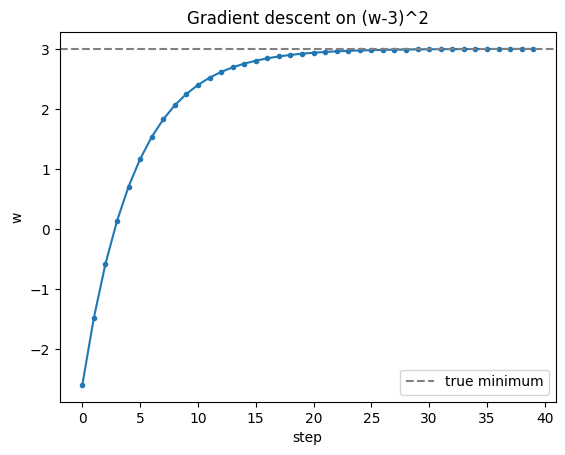

In [12]:
# ---- Minimise L(w) = (w - 3)^2 with plain gradient descent ----
w = torch.tensor(-4.0, requires_grad=True)      # Start far from the answer
lr = 0.1                                        # Learning rate (step size)
trajectory = []                                 # Record w at each step for plotting

for step in range(40):
    loss = (w - 3) ** 2                         # 1) Forward: compute the loss
    loss.backward()                             # 2) Backward: compute dL/dw
    with torch.no_grad():                       # 3) Update weights WITHOUT recording it in the graph
        w -= lr * w.grad                        #    Step opposite to the gradient
    w.grad.zero_()                              # 4) Clear the gradient for the next iteration
    trajectory.append(w.item())                 # w.item() is the current weight
    if step % 8 == 0:
        print(f"step {step:2d}: w = {w.item():.4f}, loss = {loss.item():.4f}")

plt.plot(trajectory, marker=".")                # Visualise w converging towards 3
plt.axhline(3, color="gray", linestyle="--", label="true minimum")
plt.xlabel("step"); plt.ylabel("w"); plt.title("Gradient descent on (w-3)^2"); plt.legend(); plt.show()

---
# Part 2 — Neural Networks

A neural network is a stack of simple functions. Each **layer** computes

$$\mathbf{z} = W\mathbf{x} + \mathbf{b}, \qquad \mathbf{a} = \sigma(\mathbf{z})$$

- $W, \mathbf{b}$ are learnable **weights** and **biases** (a linear transformation),
- $\sigma$ is a non-linear **activation function**.

Training repeats four steps: **forward pass** → **loss** → **backpropagation** (gradients) → **gradient descent** (update).

## 2.1 The forward pass of a single neuron (and a layer)

In [13]:
# ---- One neuron computed by hand, then a full layer with nn.Linear ----
x = torch.tensor([1.0, 2.0, 3.0])               # An input with 3 features
w = torch.tensor([0.2, -0.5, 0.1])              # One weight per input feature
b = torch.tensor(0.4)                           # A single bias

z = torch.dot(w, x) + b                         # Weighted sum: 0.2 - 1.0 + 0.3 + 0.4 = -0.1
a = torch.sigmoid(z)                            # Activation squashes z into (0, 1)
print(f"z = {z.item():.3f}, sigmoid(z) = {a.item():.3f}")

layer = nn.Linear(in_features=3, out_features=4)  # A layer of 4 neurons, each looking at 3 inputs, already initializes the weights (uses Kaiming [He] unifrom initialization)
print("weight shape:", layer.weight.shape)      # (4, 3): one row of weights per neuron
print("bias shape:  ", layer.bias.shape)        # (4,):   one bias per neuron
out = layer(x)                                  # Computes W @ x + b for all 4 neurons at once, effectively the forward pass
print("layer output:", out)

manual = layer.weight @ x + layer.bias          # Exactly the same computation written out
print("matches manual W@x+b:", torch.allclose(out, manual))

z = -0.100, sigmoid(z) = 0.475
weight shape: torch.Size([4, 3])
bias shape:   torch.Size([4])
layer output: tensor([-0.6592, -1.2309, -0.8813, -0.6420], grad_fn=<ViewBackward0>)
matches manual W@x+b: True


## 2.2 Activation functions

Without a non-linearity, stacking layers collapses into one big linear function, so the network could only draw straight decision boundaries. Activations add the "bends".

| Activation | Formula | Output range | Typical use |
|---|---|---|---|
| Sigmoid | $\frac{1}{1+e^{-z}}$ | (0, 1) | Binary output probability |
| Tanh | $\frac{e^z-e^{-z}}{e^z+e^{-z}}$ | (−1, 1) | Hidden layers (zero-centred) |
| ReLU | $\max(0, z)$ | [0, ∞) | Default for hidden layers |
| Softmax | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | probabilities summing to 1 | Multi-class output |

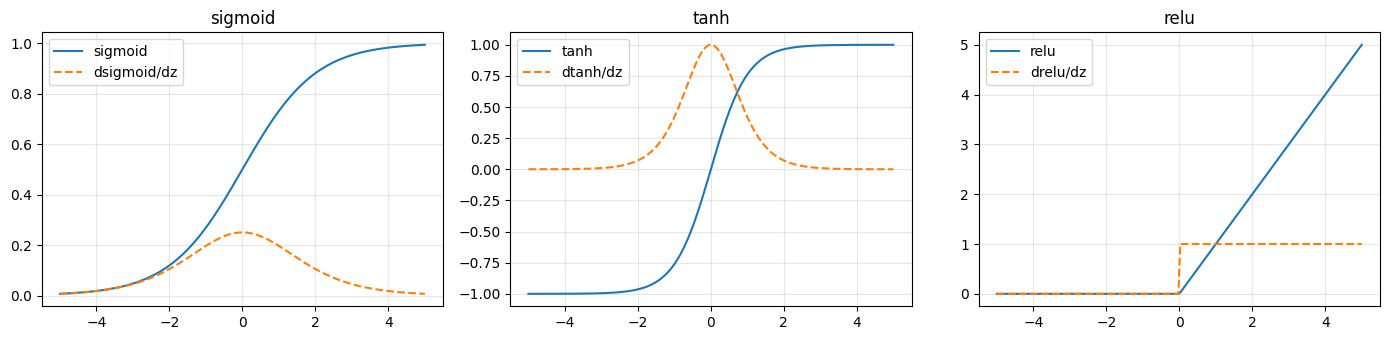

In [14]:
# ---- Plot each activation and its derivative (computed with autograd) ----
z = torch.linspace(-5, 5, 200, requires_grad=True)  # 200 points; track gradients to get derivatives

activations = {
    "sigmoid": torch.sigmoid,                   # Squashes to (0, 1)
    "tanh": torch.tanh,                         # Squashes to (-1, 1)
    "relu": torch.relu,                         # Zero for negatives, identity for positives
}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, fn) in zip(axes, activations.items()):
    out = fn(z)                                 # Apply the activation
    grad, = torch.autograd.grad(out.sum(), z)   # Derivative at every point (sum() makes it scalar)
    ax.plot(z.detach(), out.detach(), label=name)          # The activation itself
    ax.plot(z.detach(), grad, "--", label=f"d{name}/dz")    # Its derivative
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Observe: sigmoid's derivative never exceeds 0.25, so gradients shrink as they pass through
# many sigmoid layers ("vanishing gradients"). ReLU's derivative is exactly 1 for positive inputs.

In [15]:
# ---- Softmax turns arbitrary scores ("logits") into a probability distribution ----
logits = torch.tensor([2.0, 1.0, 0.1])          # Raw scores for 3 classes
probs = F.softmax(logits, dim=0)                # exp(z_i) / sum_j exp(z_j)
print("probabilities:", probs)                  # Largest logit -> largest probability
print("sum:", probs.sum().item())               # Always sums to 1

probabilities: tensor([0.6590, 0.2424, 0.0986])
sum: 1.0000001192092896


## 2.3 Backpropagation by hand (and checking it against autograd)

We'll train a 2-layer network on **XOR**, the classic problem that no single straight line can solve:

| $x_1$ | $x_2$ | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

**Network:** input (2) → hidden (4, tanh) → output (1, sigmoid), trained with either binary cross-entropy (BCE) or mean squared error (MSE).

<br>

### Forward pass

$$Z_1 = XW_1 + b_1$$

$$A_1 = \tanh(Z_1)$$

$$Z_2 = A_1W_2 + b_2$$

$$\hat{Y} = \sigma(Z_2)$$

<br>

### Loss (choose one)

**Binary cross-entropy**

$$L_{\text{BCE}} = -\frac{1}{N}\sum_{n=1}^{N}\Big[\,y_n \ln \hat{y}_n + (1 - y_n)\ln(1 - \hat{y}_n)\,\Big]$$

**Mean squared error**

$$L_{\text{MSE}} = \frac{1}{N}\sum_{n=1}^{N}\big(\hat{y}_n - y_n\big)^2$$

<br>

### Backward pass, step 1: the only step that depends on the loss

By the chain rule, $\dfrac{\partial L}{\partial Z_2} = \dfrac{\partial L}{\partial \hat{Y}} \odot \sigma'(Z_2)$, where $\sigma'(Z_2) = \hat{Y}(1 - \hat{Y})$.

<br>

**BCE:** the sigmoid derivative cancels out

$$\frac{\partial L}{\partial \hat{Y}} = \frac{1}{N}\cdot\frac{\hat{Y} - Y}{\hat{Y}(1 - \hat{Y})} \qquad\Longrightarrow\qquad \frac{\partial L}{\partial Z_2} = \frac{\hat{Y} - Y}{N}$$

<br>

**MSE:** the sigmoid derivative stays

$$\frac{\partial L}{\partial \hat{Y}} = \frac{2}{N}\big(\hat{Y} - Y\big) \qquad\Longrightarrow\qquad \frac{\partial L}{\partial Z_2} = \frac{2}{N}\big(\hat{Y} - Y\big) \odot \hat{Y}\big(1 - \hat{Y}\big)$$

<br>

> **Why it matters:** with MSE, the factor $\hat{Y}(1 - \hat{Y})$ approaches 0 whenever the output is near 0 or 1, including when the prediction is confidently *wrong*. The gradient then becomes tiny and

In [16]:
# ---- XOR data and randomly initialised weights ----
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])  # 4 examples, 2 features each -> (4, 2)
Y = torch.tensor([[0.], [1.], [1.], [0.]])                   # Targets -> (4, 1)

torch.manual_seed(0)                            # Fixed seed so the run is reproducible
W1 = torch.randn(2, 4) * 0.5                    # Input->hidden weights (2 inputs, 4 hidden units)
b1 = torch.zeros(4)                             # Hidden biases
W2 = torch.randn(4, 1) * 0.5                    # Hidden->output weights
b2 = torch.zeros(1)                             # Output bias


def forward(X, W1, b1, W2, b2):
    # ---- Forward pass: returns every intermediate value (backprop needs them) ----
    Z1 = X @ W1 + b1                            # Linear step for the hidden layer -> (N, 4)
    A1 = torch.tanh(Z1)                         # Hidden activations -> (N, 4)
    Z2 = A1 @ W2 + b2                           # Linear step for the output layer -> (N, 1)
    A2 = torch.sigmoid(Z2)                      # Predicted probability of class 1 -> (N, 1)
    return Z1, A1, Z2, A2


def bce_loss(A2, Y):
    # ---- Binary cross-entropy averaged over examples ----
    eps = 1e-8                                  # Avoid log(0)
    return -(Y * torch.log(A2 + eps) + (1 - Y) * torch.log(1 - A2 + eps)).mean()


def backward(X, Y, A1, A2, W2):
    # ---- Backward pass: the chain-rule formulas from the markdown cell above ----
    N = X.shape[0]                              # Number of examples (we averaged the loss over them)
    dZ2 = (A2 - Y) / N                          # dL/dZ2 -> (N, 1)
    dW2 = A1.T @ dZ2                            # dL/dW2 -> (4, 1)
    db2 = dZ2.sum(dim=0)                        # dL/db2 -> (1,)
    dA1 = dZ2 @ W2.T                            # Send the error back to the hidden layer -> (N, 4)
    dZ1 = dA1 * (1 - A1 ** 2)                   # Multiply by tanh'(Z1) -> (N, 4)
    dW1 = X.T @ dZ1                             # dL/dW1 -> (2, 4)
    db1 = dZ1.sum(dim=0)                        # dL/db1 -> (4,)
    return dW1, db1, dW2, db2


def mse_loss(A2, Y):
    return ((A2 - Y) ** 2).mean()               # Mean squared error

def backward_mse(X, Y, A1, A2, W2):
    N = X.shape[0]
    dZ2 = 2 * (A2 - Y) * A2 * (1 - A2) / N      # Only this line changes: sigmoid'(Z2) no longer cancels
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(dim=0)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1 - A1 ** 2)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(dim=0)
    return dW1, db1, dW2, db2

In [17]:
# ---- Sanity check for BCE: our hand-derived gradients should equal PyTorch's autograd ----
_, A1, _, A2 = forward(X, W1, b1, W2, b2)       # Forward pass with plain tensors
manual_grads = backward(X, Y, A1, A2, W2)       # Our gradients

params = [p.clone().requires_grad_(True) for p in (W1, b1, W2, b2)]  # Copies that autograd can track
_, _, _, A2_auto = forward(X, *params)          # Same forward pass, but recorded
F.binary_cross_entropy(A2_auto, Y).backward()   # PyTorch's own BCE + automatic backprop

for name, g_manual, p in zip(["W1", "b1", "W2", "b2"], manual_grads, params):
    print(f"{name}: manual == autograd ? {torch.allclose(g_manual, p.grad, atol=1e-6)}")

W1: manual == autograd ? True
b1: manual == autograd ? True
W2: manual == autograd ? True
b2: manual == autograd ? True


In [18]:
# ---- Sanity check for MSE: hand-derived gradients vs. PyTorch's autograd ----
_, A1, _, A2 = forward(X, W1, b1, W2, b2)       # Forward pass with plain tensors
manual_grads = backward_mse(X, Y, A1, A2, W2)   # Our MSE gradients (includes the sigmoid' factor)

params = [p.clone().requires_grad_(True) for p in (W1, b1, W2, b2)]  # Fresh copies that autograd can track
_, _, _, A2_auto = forward(X, *params)          # Same forward pass, but recorded
F.mse_loss(A2_auto, Y).backward()               # PyTorch's mean squared error + automatic backprop

for name, g_manual, p in zip(["W1", "b1", "W2", "b2"], manual_grads, params):
    print(f"{name}: manual == autograd ? {torch.allclose(g_manual, p.grad, atol=1e-6)}")

W1: manual == autograd ? True
b1: manual == autograd ? True
W2: manual == autograd ? True
b2: manual == autograd ? True


## 2.4 Gradient descent: the full training loop (manual version)

In [19]:
# ---- Train the XOR network twice (BCE vs MSE) from IDENTICAL starting weights ----
def train_manual(loss_fn, backward_fn, init_params, lr=1.0, steps=3001, label=""):
    # ---- One manual training run; returns final params and the loss history ----
    W1, b1, W2, b2 = [p.clone() for p in init_params]  # Copies, so each run starts from the same point
    losses = []
    for step in range(steps):
        Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)    # 1) Forward pass
        loss = loss_fn(A2, Y)                          # 2) Measure how wrong we are
        dW1, db1, dW2, db2 = backward_fn(X, Y, A1, A2, W2)  # 3) Backpropagation
        W1 -= lr * dW1; b1 -= lr * db1                 # 4) Gradient-descent update, layer 1
        W2 -= lr * dW2; b2 -= lr * db2                 #    Gradient-descent update, layer 2
        losses.append(loss.item())
        if step % 500 == 0:
            print(f"[{label}] step {step:4d} | loss {loss.item():.4f}")
    _, _, _, A2 = forward(X, W1, b1, W2, b2)           # Final predictions
    print(f"[{label}] probabilities:", A2.squeeze().round(decimals=3).tolist())
    print(f"[{label}] classes:      ", (A2 > 0.5).int().squeeze().tolist(), " (target: [0, 1, 1, 0])\n")
    return (W1, b1, W2, b2), losses


# ---- Re-create the ORIGINAL starting weights (the earlier cell already trained W1..b2 in place) ----
torch.manual_seed(0)                            # Same seed as the XOR data cell
init = (torch.randn(2, 4) * 0.5,                # W1
        torch.zeros(4),                         # b1
        torch.randn(4, 1) * 0.5,                # W2
        torch.zeros(1))                         # b2

params_bce, losses_bce = train_manual(bce_loss, backward,     init, lr=1.0, label="BCE")
params_mse, losses_mse = train_manual(mse_loss, backward_mse, init, lr=1.0, label="MSE")

[BCE] step    0 | loss 0.6976
[BCE] step  500 | loss 0.0093
[BCE] step 1000 | loss 0.0030
[BCE] step 1500 | loss 0.0018
[BCE] step 2000 | loss 0.0013
[BCE] step 2500 | loss 0.0010
[BCE] step 3000 | loss 0.0008
[BCE] probabilities: [0.0, 0.9990000128746033, 0.9990000128746033, 0.0010000000474974513]
[BCE] classes:       [0, 1, 1, 0]  (target: [0, 1, 1, 0])

[MSE] step    0 | loss 0.2521
[MSE] step  500 | loss 0.0032
[MSE] step 1000 | loss 0.0010
[MSE] step 1500 | loss 0.0006
[MSE] step 2000 | loss 0.0004
[MSE] step 2500 | loss 0.0003
[MSE] step 3000 | loss 0.0003
[MSE] probabilities: [0.007000000216066837, 0.9829999804496765, 0.9829999804496765, 0.01899999938905239]
[MSE] classes:       [0, 1, 1, 0]  (target: [0, 1, 1, 0])



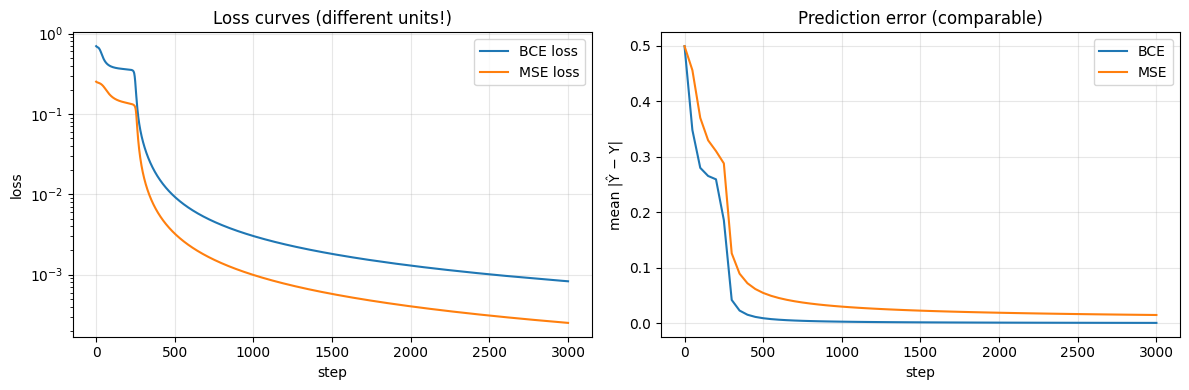

Final mean |Ŷ − Y|  BCE: 0.0008   MSE: 0.0150


In [20]:
# ---- Overlay the loss curves, plus a metric both runs can be compared on fairly ----
def mean_abs_error(params):
    # Average distance between predicted probability and target: same units for both runs
    _, _, _, A2 = forward(X, *params)
    return (A2 - Y).abs().mean().item()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_bce, label="BCE loss")          # Each curve in its own loss's units
ax1.plot(losses_mse, label="MSE loss")
ax1.set_xlabel("step"); ax1.set_ylabel("loss"); ax1.set_yscale("log")  # Log scale shows late-stage progress
ax1.set_title("Loss curves (different units!)"); ax1.legend(); ax1.grid(alpha=0.3)

# Re-run both trainings while recording mean |Ŷ - Y| every 50 steps (same units for both)
def track_error(loss_fn, backward_fn, lr=1.0, steps=3001, every=50):
    W1, b1, W2, b2 = [p.clone() for p in init]
    history = []
    for step in range(steps):
        _, A1, _, A2 = forward(X, W1, b1, W2, b2)
        if step % every == 0:
            history.append((step, (A2 - Y).abs().mean().item()))
        dW1, db1, dW2, db2 = backward_fn(X, Y, A1, A2, W2)
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return zip(*history)

for name, lf, bf in [("BCE", bce_loss, backward), ("MSE", mse_loss, backward_mse)]:
    steps_, errs = track_error(lf, bf)
    ax2.plot(steps_, errs, label=name)
ax2.set_xlabel("step"); ax2.set_ylabel("mean |Ŷ − Y|")
ax2.set_title("Prediction error (comparable)"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Final mean |Ŷ − Y|  BCE: {mean_abs_error(params_bce):.4f}   MSE: {mean_abs_error(params_mse):.4f}")

## 2.5 The same thing, the PyTorch way

In practice you never write `backward()` yourself. You:

1. Subclass `nn.Module` and describe the **forward pass** only.
2. Pick a **loss function** (`nn.BCELoss`, `nn.CrossEntropyLoss`, ...).
3. Pick an **optimizer** (`torch.optim.SGD`, `Adam`, ...), which performs the update rule.

Every PyTorch training loop is then the same 5 lines: `zero_grad` → forward → loss → `backward` → `step`.

In [21]:
# ---- XOR again, with nn.Module + autograd + an optimizer ----
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()                      # Always call the parent constructor first
        self.hidden = nn.Linear(2, 4)           # Layer 1: 2 -> 4 (holds W1, b1)
        self.out = nn.Linear(4, 1)              # Layer 2: 4 -> 1 (holds W2, b2)

    def forward(self, x):
        h = torch.tanh(self.hidden(x))          # Hidden layer + activation
        return torch.sigmoid(self.out(h))       # Output probability


torch.manual_seed(0)
model = XORNet()                                # Create the network (weights initialised randomly)
loss_fn = nn.BCELoss()                          # Binary cross-entropy
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)  # Plain gradient descent on all parameters

for step in range(3001):
    optimizer.zero_grad()                       # 1) Clear old gradients (they accumulate)
    preds = model(X)                            # 2) Forward pass
    loss = loss_fn(preds, Y)                    # 3) Compute the loss
    loss.backward()                             # 4) Backprop: fills .grad of every parameter
    optimizer.step()                            # 5) Update: p -= lr * p.grad
    if step % 1000 == 0:
        print(f"step {step:4d} | loss {loss.item():.4f}")

print("Entries :", X)
print("Predicted probabilities:", preds.squeeze().round(decimals=3).tolist())

with torch.no_grad():                           # No gradients needed for inference
    print("Predicted classes:", (model(X) > 0.5).int().squeeze().tolist())

step    0 | loss 0.6996
step 1000 | loss 0.0013
step 2000 | loss 0.0006
step 3000 | loss 0.0004
Entries : tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Predicted probabilities: [0.0, 1.0, 1.0, 0.0]
Predicted classes: [0, 1, 1, 0]


---
# Part 4 — Continuous Bag of Words (CBOW) from Scratch

**Word2Vec** learns embeddings with *no labels at all*, using the **distributional hypothesis**: *words that appear in similar contexts have similar meanings.*

**CBOW** turns raw text into a prediction task: given the surrounding words (the **context**), predict the missing middle word (the **target**).

```
sentence:  the  cat  runs  in  the  field        window = 2
                     ^^^^
context = [the, cat, in, the]   ->   target = runs
```

**Architecture**

CBOW has three steps: **average** the context word vectors, **score** every vocabulary word against that average, and turn the scores into **probabilities**.

<br>

### The two learnable matrices

- $E$ is a $V \times D$ **embedding matrix**. Row $i$, written $E[i]$, is the input vector for word $i$.
- $U$ is a $V \times D$ **output matrix**. Row $j$, written $\mathbf{u}_j$, is the output vector for word $j$, used when $j$ is the candidate target. $\mathbf{b}$ holds one bias per word.

Every word therefore has **two** vectors: one used when it appears *in* a context, and one used when it is the word being *predicted*.

<br>

### Step 1: Summarise the context

$$\mathbf{h} = \frac{1}{|C|}\sum_{c \in C} E[c]$$

- $C$ is the set of real context words: up to $w$ on each side, so $|C| = 2w$ in the middle of a sentence and fewer near the edges.
- $E[c]$ looks up the row of $E$ for word $c$. This is exactly what `self.embeddings(context)` does.
- $\mathbf{h}$ is a single $D$-dimensional vector summarising what surrounds the gap.
- **Shapes:** $E[c]$ is $(D,)$ and $\mathbf{h}$ is $(D,)$. With a batch, $\mathbf{h}$ is $(B, D)$.

> **Code:** `h = (emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)` — the mask makes $|C|$ count only real words, so `<pad>` never dilutes the average.

Averaging ignores word order. "the ___ runs in" and "in runs the ___" give the same $\mathbf{h}$, which is why it's called a **bag** of words.

<br>

### Step 2: Score every word in the vocabulary

$$\text{scores} = U\mathbf{h} + \mathbf{b} \qquad\Longleftrightarrow\qquad \text{score}_j = \mathbf{u}_j \cdot \mathbf{h} + b_j \quad \text{for every word } j$$

- Each score is a **dot product**, which is large when $\mathbf{u}_j$ points in the same direction as $\mathbf{h}$. A high score means word $j$ fits this context well.
- The bias $b_j$ lets common words, like "the", get a head start regardless of context.
- **Shapes:** $U$ is $(V, D)$ and $\mathbf{h}$ is $(D,)$, so scores are $(V,)$: one number per vocabulary word.

> **Code:** `return self.output(h)` — `nn.Linear(D, V)` stores $U$ and $\mathbf{b}$ and computes all $V$ dot products in one matrix multiplication.

<br>

### Step 3: Turn scores into probabilities

$$P(j \mid \text{context}) = \text{softmax}(\text{scores})_j = \frac{e^{\text{score}_j}}{\sum_{k=1}^{V} e^{\text{score}_k}}$$

- Exponentiating makes every score positive, and dividing by the total makes them sum to 1.
- **Shapes:** a probability vector of shape $(V,)$.

> **Code:** there is no softmax line in `forward`. `nn.CrossEntropyLoss` applies softmax internally, which is faster and numerically safer.

<br>

### A small example ($D = 2$, three candidate words, biases 0)

Context: "the ___ runs in", with $\mathbf{h} = (0.4,\ 0.2)$.

| word $j$ | $\mathbf{u}_j$ | $\text{score}_j = \mathbf{u}_j \cdot \mathbf{h}$ | $P(j \mid \text{context})$ [or softmax] |
|---|---|---|---|
| cat | (2.0, 1.0) | 0.80 + 0.20 = **1.00** | 0.448 |
| dog | (1.8, 1.2) | 0.72 + 0.24 = **0.96** | 0.430 |
| car | (−1.0, 0.5) | −0.40 + 0.10 = **−0.30** | 0.122 |

*cat* and *dog* have output vectors pointing roughly the same way as $\mathbf{h}$, so both get high, nearly equal probability. *car* points away and gets little. A trained model looks like this: it can't tell *which* animal fills the gap, but it knows the gap holds *an animal*.

<br>

### Step 4: The loss

$$L = -\ln P(\text{target} \mid \text{context})$$

averaged over the batch. If the true target is *cat*, the loss for the example above is $-\ln 0.448 = 0.80$. A perfect, certain prediction would give $L = 0$, and a uniform guess over $V$ words gives $L = \ln V$.

<br>

### What training does to the vectors

Each gradient step makes three kinds of change:

1. The **target's output vector** $\mathbf{u}_{\text{target}}$ moves **toward** $\mathbf{h}$, so it scores higher next time.
2. The **other output vectors** $\mathbf{u}_j$ move **away from** $\mathbf{h}$, each in proportion to how much probability it wrongly received.
3. The **context words' input vectors** $E[c]$ move so that their average $\mathbf{h}$ points **toward** $\mathbf{u}_{\text{target}}$.

Now suppose *cat* and *dog* keep appearing in the same contexts. The same kinds of $\mathbf{h}$ keep pulling both of their output vectors in the same direction. Going the other way, words that tend to surround the same targets get their input vectors shaped the same way. After thousands of updates, **words used in similar contexts end up with similar vectors.**

<br>

### Reading out the embeddings

After training, **row $i$ of $E$ is the dense embedding of word $i$.** That is the whole trick: we never cared about predicting the missing word itself. The prediction task is just a way to force $E$ to organise words by how they are used.

> **Code:** `cbow_model.embeddings.weight` is $E$, a $(V, D)$ matrix with one embedding per row.

## 4.1 A toy corpus with clear word groups

We generate sentences from four topics. Words within a topic (e.g. *cat, dog, horse, rabbit*) share contexts, so a working CBOW should place them close together.

In [22]:
# ---- Generate a synthetic corpus where each topic has its own contexts ----
random.seed(0)                                  # Reproducible corpus

WORD_GROUPS = {                                 # Topic -> words we hope will cluster together (10 per group)
    "animal":  ["cat", "dog", "horse", "rabbit", "cow", "sheep", "goat", "pig", "duck", "mouse"],
    "fruit":   ["apple", "banana", "mango", "orange", "grape", "pear", "peach", "cherry", "lemon", "plum"],
    "royalty": ["king", "queen", "prince", "princess", "emperor", "empress", "duke", "duchess", "monarch", "sultan"],
    "vehicle": ["car", "bus", "truck", "van", "taxi", "jeep", "tractor", "motorcycle", "scooter", "ambulance"],
}
CONTEXT_TEMPLATES = {                           # Topic -> sentence patterns; {w} is replaced by a group word
    "animal":  ["the {w} runs in the field", "the {w} sleeps on the grass",
                "my {w} eats its food", "a small {w} plays outside",
                "the {w} drinks water from the pond", "we fed the hungry {w}",
                "the farmer owns a {w}", "the {w} hid behind the barn"],
    "fruit":   ["i eat a fresh {w}", "the {w} is sweet and juicy",
                "she bought a ripe {w}", "we made juice from the {w}",
                "he peeled the {w} slowly", "the {w} grew on the tree",
                "she added the {w} to the salad", "a ripe {w} fell to the ground"],
    "royalty": ["the {w} rules the kingdom", "the {w} lives in the castle",
                "the royal {w} wore a crown", "people bow to the {w}",
                "the {w} sat on the throne", "the young {w} gave a speech",
                "guards protected the {w}", "the {w} signed a royal decree"],
    "vehicle": ["i drive the {w} to work", "the {w} is parked on the street",
                "the {w} needs more fuel", "the {w} stopped at the red light",
                "the {w} drove down the highway", "he washed the dirty {w}",
                "the {w} has a flat tire", "we rode the {w} into town"],
}

N_ROUNDS = 250                                  # 250 rounds x 4 topics = 1000 sentences
corpus_sentences = []
for _ in range(N_ROUNDS):
    for topic, words in WORD_GROUPS.items():
        template = random.choice(CONTEXT_TEMPLATES[topic])  # Random pattern from this topic
        corpus_sentences.append(template.format(w=random.choice(words)))  # Random word from this topic

tokenized_corpus = [s.split() for s in corpus_sentences]  # List of token lists (gensim uses this format too)
print("Sentences:", len(tokenized_corpus))
print("Corpus Examples:", corpus_sentences[:4])
print("Tokenized Corpus Examples:", tokenized_corpus[:4])

# ---- Check that every group word got enough examples to learn from ----
word_counts_corpus = Counter(tok for sent in tokenized_corpus for tok in sent)
for topic, words in WORD_GROUPS.items():
    counts = [word_counts_corpus[w] for w in words]
    print(f"{topic:8s} occurrences per word: min {min(counts)}, max {max(counts)}")

Sentences: 1000
Corpus Examples: ['the farmer owns a goat', 'i eat a fresh grape', 'the duke signed a royal decree', 'the motorcycle drove down the highway']
Tokenized Corpus Examples: [['the', 'farmer', 'owns', 'a', 'goat'], ['i', 'eat', 'a', 'fresh', 'grape'], ['the', 'duke', 'signed', 'a', 'royal', 'decree'], ['the', 'motorcycle', 'drove', 'down', 'the', 'highway']]
animal   occurrences per word: min 18, max 34
fruit    occurrences per word: min 16, max 34
royalty  occurrences per word: min 17, max 33
vehicle  occurrences per word: min 17, max 32


## 4.2 Vocabulary and (context, target) training pairs

Words near the edge of a sentence have fewer than $2w$ neighbours, so we fill the missing slots with `<pad>` and ignore them when averaging.

In [23]:
# ---- Vocabulary for the CBOW corpus ----

# Count how often each word appears across all sentences.
# e.g. {"holmes": 412, "watson": 180, "the": 3051, ...}
counts = Counter(tok for sent in tokenized_corpus for tok in sent)

# Keep words seen at least MIN_COUNT times (5 is word2vec's default).
# Rarer words get too few updates to learn a useful vector.
MIN_COUNT = 5
kept_words = sorted(w for w, c in counts.items() if c >= MIN_COUNT)

# ID 0 is reserved for padding, so real words start at 1.
# e.g. ["<pad>", "a", "abandoned", "able", ...]
cbow_itos = ["<pad>"] + kept_words               # id -> word
cbow_stoi = {w: i for i, w in enumerate(cbow_itos)}  # word -> id, e.g. {"<pad>": 0, "a": 1, ...}
CBOW_PAD = 0
V = len(cbow_itos)                               # vocabulary size, including <pad>

# Remove filtered-out words from each sentence, then drop sentences
# that end up empty.
# e.g. ["holmes", "examined", "the", "quixotic", "parcel"]
#   -> ["holmes", "examined", "the", "parcel"]   (if "quixotic" was rare)
tokenized_corpus = [[t for t in sent if t in cbow_stoi] for sent in tokenized_corpus]
tokenized_corpus = [sent for sent in tokenized_corpus if sent]

print("Vocabulary size V =", V)
print(f"Dropped {len(counts) - len(kept_words)} rare words (count < {MIN_COUNT})")

print("Sentences:", len(tokenized_corpus))
print("Tokenized Corpus Examples:", tokenized_corpus[:4])

Vocabulary size V = 130
Dropped 0 rare words (count < 5)
Sentences: 1000
Tokenized Corpus Examples: [['the', 'farmer', 'owns', 'a', 'goat'], ['i', 'eat', 'a', 'fresh', 'grape'], ['the', 'duke', 'signed', 'a', 'royal', 'decree'], ['the', 'motorcycle', 'drove', 'down', 'the', 'highway']]


In [24]:
# ---- Slide a window over every sentence to create training pairs ----
WINDOW = 2                                      # Words on EACH side of the target

def make_cbow_pairs(tokenized, window):
    contexts, targets = [], []
    for sent in tokenized:
        ids = [cbow_stoi[w] for w in sent]      # Convert the sentence as strings into sentence as ids
        for i in range(len(ids)):               # Every position takes a turn as the target
            ctx = []
            for j in range(i - window, i + window + 1):  # Positions around the target
                if j == i:
                    continue                    # Skip the target itself
                ctx.append(ids[j] if 0 <= j < len(ids) else CBOW_PAD)  # Out of bounds -> <pad>
            contexts.append(ctx)                # Always exactly 2*window ids
            targets.append(ids[i])              # The word at position i is the target
    return torch.tensor(contexts), torch.tensor(targets)

cbow_X, cbow_y = make_cbow_pairs(tokenized_corpus, WINDOW)
print("contexts:", tuple(cbow_X.shape), " targets:", tuple(cbow_y.shape))
# shape (N, 4): N examples, 4 context IDs each
# shape (N,):   one target ID per example
print()

for k in range(3):                              # Show a few pairs in words, not ids
    print("Sentence #", k+1)
    print([i for i in cbow_X[k]], "->", cbow_y[k])
    print([cbow_itos[i] for i in cbow_X[k]], "->", cbow_itos[cbow_y[k]])
    print("")

contexts: (5721, 4)  targets: (5721,)

Sentence # 1
[tensor(0), tensor(0), tensor(33), tensor(79)] -> tensor(115)
['<pad>', '<pad>', 'farmer', 'owns'] -> the

Sentence # 2
[tensor(0), tensor(115), tensor(79), tensor(1)] -> tensor(33)
['<pad>', 'the', 'owns', 'a'] -> farmer

Sentence # 3
[tensor(115), tensor(33), tensor(1), tensor(43)] -> tensor(79)
['the', 'farmer', 'a', 'goat'] -> owns



In [25]:
from collections import Counter, defaultdict
import math

# Group examples by context, ignoring order and <pad> (as the averaging does)
groups = defaultdict(Counter)
for ctx, tgt in zip(cbow_X.tolist(), cbow_y.tolist()):
    key = tuple(sorted(w for w in ctx if w != CBOW_PAD))
    groups[key][tgt] += 1

# Best possible loss: predict each target with its actual frequency in that context
# Not 0 because more than one word can be assigned to a series of context words
# Also because of how the dataset was built
floor = 0.0
for tgt_counts in groups.values():      # each distinct context
    n = sum(tgt_counts.values())        # how many times it appears
    for c in tgt_counts.values():       # each target seen with it, c times
        floor -= c * math.log(c / n)    # c examples, each at best prob c/n
floor = floor / len(cbow_y)             # average over all examples, like the loss
print(f"Lowest achievable loss: {floor:.4f}")

# Show a few contexts that have more than one target
ambiguous = [(k, c) for k, c in groups.items() if len(c) > 1]
print(f"{len(ambiguous)} ambiguous contexts, e.g.:")
for key, c in ambiguous[:5]:
    print([cbow_itos[i] for i in key], "->", {cbow_itos[t]: n for t, n in c.items()})

Lowest achievable loss: 0.4511
34 ambiguous contexts, e.g.:
['a', 'owns'] -> {'goat': 2, 'mouse': 2, 'cow': 3, 'cat': 5, 'sheep': 3, 'horse': 3, 'dog': 3, 'pig': 3, 'rabbit': 1, 'duck': 3}
['a', 'fresh'] -> {'grape': 1, 'banana': 3, 'apple': 4, 'mango': 6, 'cherry': 3, 'peach': 7, 'orange': 3, 'plum': 2, 'lemon': 1, 'pear': 2}
['a', 'signed', 'the'] -> {'duke': 4, 'queen': 2, 'empress': 1, 'monarch': 3, 'prince': 2, 'king': 4, 'princess': 4, 'emperor': 1}
['down', 'drove', 'the'] -> {'motorcycle': 3, 'scooter': 3, 'bus': 4, 'jeep': 5, 'truck': 4, 'taxi': 3, 'car': 4, 'van': 2, 'ambulance': 2, 'tractor': 1}
['hungry', 'the'] -> {'mouse': 3, 'sheep': 5, 'duck': 4, 'rabbit': 2, 'dog': 3, 'horse': 4, 'goat': 4, 'cat': 2, 'cow': 3, 'pig': 1}


## 4.3 The CBOW model

In [26]:
# ---- CBOW: average the context embeddings, then score every vocabulary word ----
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx=0):
        super().__init__()

        # W: a lookup table with one D-dim row per word.
        # e.g. row 7 is the vector for word 7 ("castle", say).
        # W: (V, D) <- what we want
        # nn.Embedding works best for one-hot encoding vectors
        self.embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # W': maps a D-dim vector to V scores, one per vocabulary word.
        self.output = nn.Linear(embed_dim, vocab_size)
        self.pad_idx = pad_idx

    def forward(self, context):
        # context: (B, 4) IDs, e.g. [[upon, a, a, king]] as numbers.
        # Generally, context: (B, 2*WINDOW) word ids
        # B is the batch size

        # Look up a row of W for each context word: (B, 2W, D).
        emb = self.embeddings(context)

        # Creates the mask to filter out the pads
        # .unsqueeze(-1) adds a dimension at the end (based on the value inside unsqueeze)
        # It turns the mask from shape (B, 2W) into (B, 2W, 1), so it can be multiplied with emb, which has shape (B, 2W, D)
        # (B, 2W, 1) ignore <pad>
        mask = (context != self.pad_idx).unsqueeze(-1).float()

        # Calculates for the average of the vector representations of the context words
        # .clamp() limits values to a range (min, max) defined by the user
        # Numerator is sum of the vectors of the real context words (not <pads>)
        # Denominator is the number of real context words (not <pads>)
        # (B, D) mean context vector
        h = (emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        # (B, V) a score for every possible target word
        # No need for activation function yet, a design choice
        return self.output(h)


torch.manual_seed(SEED)
CBOW_DIM = 20                                   # Size of each word embedding
cbow_model = CBOW(V, CBOW_DIM, pad_idx=CBOW_PAD)
print(cbow_model)

CBOW(
  (embeddings): Embedding(130, 20, padding_idx=0)
  (output): Linear(in_features=20, out_features=130, bias=True)
)


## 4.4 Training

This is a V-way classification problem, so the loss is ordinary cross-entropy over the whole vocabulary ("full softmax"). That is fine for a tiny vocabulary; Part 6 explains why real implementations use tricks like *negative sampling* instead.

In [27]:
# TensorDataset pairs the two tensors row by row, so example i is
# (cbow_X[i], cbow_y[i]): e.g. ([upon, a, a, king], time) as IDs.
# DataLoader then groups examples into batches of 64 (can be changed to what we want):
#   ctx: (64, 2W) context IDs, tgt: (64,) target IDs.
# shuffle=True reshuffles the order every epoch, so the model doesn't see the text in the same sequence each time.
# The last batch may be smaller than 64 if the dataset doesn't divide evenly.
# Essentially, batches of (context, target)
cbow_loader = DataLoader(TensorDataset(cbow_X, cbow_y), batch_size=64, shuffle=True)

# Takes the raw scores (B, V) and the target IDs (B,).
# For each example it applies softmax to get probabilities, then takes
# -ln(probability of the correct word), and averages over the batch.
# e.g. correct word at prob 0.448 -> loss 0.80; at prob 1.0 -> loss 0.
cbow_loss_fn = nn.CrossEntropyLoss()

# cbow_model.parameters() hands over everything trainable:
#   E (embeddings.weight), U (output.weight), b (output.bias).
# After loss.backward() computes the gradients, cbow_opt.step() moves each weight a small step in the direction that lowers the loss.
# Adam adapts the step size for each weight individually, based on its recent gradients, so it usually trains faster than plain SGD.
# lr=0.01 is the base step size.
cbow_opt = torch.optim.Adam(cbow_model.parameters(), lr=0.01)

epoch  1 | loss 3.7115
epoch 10 | loss 0.5043
epoch 20 | loss 0.4829
epoch 30 | loss 0.4770
epoch 40 | loss 0.4743
epoch 50 | loss 0.4717
epoch 60 | loss 0.4721
epoch 70 | loss 0.4700
epoch 80 | loss 0.4693
epoch 90 | loss 0.4692
epoch 100 | loss 0.4692


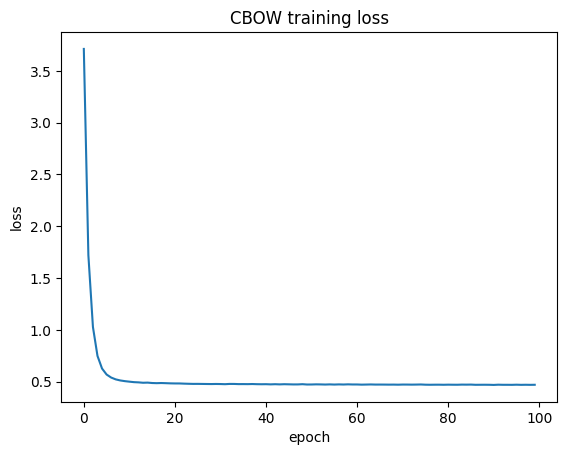

In [28]:
# ---- Standard mini-batch training loop ----
cbow_losses = []
for epoch in range(1, 101):
    total = 0.0
    for ctx, tgt in cbow_loader:
        cbow_opt.zero_grad()                    # 1) Reset gradients
        logits = cbow_model(ctx)                # 2) Forward: (B, V) scores
        loss = cbow_loss_fn(logits, tgt)        # 3) How well did we predict the middle word?
        loss.backward()                         # 4) Backprop into BOTH the output layer and the embeddings
        cbow_opt.step()                         # 5) Update weights and biases
        total += loss.item() * len(tgt)
    cbow_losses.append(total / len(cbow_y))
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:2d} | loss {cbow_losses[-1]:.4f}")

plt.plot(cbow_losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("CBOW training loss"); plt.show()

In [29]:
# ---- Check all learned parameters after training ----
for name, param in cbow_model.named_parameters():
    print(f"{name:20s} shape {tuple(param.shape)}")
# Expected:
# embeddings.weight    shape (V, D)   ← E, the word vectors we want
# output.weight        shape (V, D)   ← U, one output vector per word
# output.bias          shape (V,)     ← b, one bias per word (only if bias=True)

# padding_idx should have kept the <pad> row at zero throughout training
pad_row = cbow_model.embeddings.weight[CBOW_PAD]
print("<pad> row all zeros:", bool((pad_row == 0).all()))

embeddings.weight    shape (130, 20)
output.weight        shape (130, 20)
output.bias          shape (130,)
<pad> row all zeros: True


## 4.5 Extracting dense embeddings for every word

The trained embedding table **is** the set of word vectors. There are two equivalent ways to read it:

1. Take the whole weight matrix: `model.embeddings.weight` → shape $(V, D)$, row *i* = word *i*.
2. Look up individual words by passing their ids through the layer: `model.embeddings(torch.tensor([id]))`.

In [30]:
# ---- Pull out the embedding matrix and build a word -> vector dictionary ----
cbow_matrix = cbow_model.embeddings.weight.detach().clone()  # (V, D); detach: no gradient history needed
print("Embedding matrix shape:", tuple(cbow_matrix.shape))

cbow_vectors = {word: cbow_matrix[idx]          # Every vocabulary word -> its D-dimensional vector
                for idx, word in enumerate(cbow_itos) if word != "<pad>"}
print("Number of word vectors:", len(cbow_vectors))
print("Vector for 'king':", cbow_vectors["king"].round(decimals=2))

same = cbow_model.embeddings(torch.tensor([cbow_stoi["king"]]))[0].detach()  # Method 2: layer lookup
print("Both methods agree:", torch.allclose(same, cbow_vectors["king"]))

Embedding matrix shape: (130, 20)
Number of word vectors: 129
Vector for 'king': tensor([ 1.1800,  0.9100,  2.0800,  3.1600, -2.7100, -0.7600, -0.1900,  2.4100,
         2.0100,  1.7900, -1.8600,  0.3300,  2.7700, -2.9600, -1.4600, -2.5400,
         0.3700, -2.0600, -1.5000, -3.4300])
Both methods agree: True


In [31]:
# ---- Cosine similarity and nearest neighbours ----
def cosine(u, v):
    return F.cosine_similarity(u.unsqueeze(0), v.unsqueeze(0)).item()


def most_similar(word, matrix, stoi, itos, topn=5):
    normed = F.normalize(matrix, dim=1)         # Scale every row to length 1
    sims = normed @ normed[stoi[word]]          # Dot product of unit vectors = cosine similarity with every word
    results = []
    for idx in sims.argsort(descending=True).tolist():  # Most similar first
        if itos[idx] in (word, "<pad>"):
            continue                            # Skip the query word itself and padding
        results.append((itos[idx], round(sims[idx].item(), 3)))
        if len(results) == topn:
            break
    return results


print("cos(cat, dog)   =", round(cosine(cbow_vectors["cat"], cbow_vectors["dog"]), 3))
print("cos(cat, truck) =", round(cosine(cbow_vectors["cat"], cbow_vectors["truck"]), 3))
for w in ["cat", "apple", "king", "car"]:
    print(f"{w:6s} ->", most_similar(w, cbow_matrix, cbow_stoi, cbow_itos, topn=4))

cos(cat, dog)   = 0.96
cos(cat, truck) = 0.128
cat    -> [('horse', 0.984), ('cow', 0.97), ('mouse', 0.961), ('dog', 0.96)]
apple  -> [('cherry', 0.986), ('pear', 0.986), ('mango', 0.968), ('orange', 0.959)]
king   -> [('queen', 0.971), ('princess', 0.958), ('empress', 0.955), ('sultan', 0.949)]
car    -> [('scooter', 0.978), ('motorcycle', 0.974), ('jeep', 0.966), ('taxi', 0.965)]


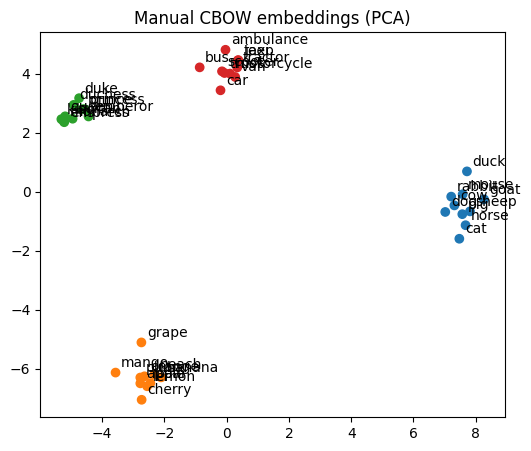

In [32]:
# ---- Visualise the embeddings in 2-D with PCA ----
from sklearn.decomposition import PCA           # Projects high-dimensional vectors onto 2 axes

def plot_embeddings_2d(vector_lookup, title):
    words, colors, vecs = [], [], []
    palette = dict(zip(WORD_GROUPS, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))  # Topic -> colour
    for topic, group in WORD_GROUPS.items():
        for w in group:
            words.append(w); colors.append(palette[topic])
            vecs.append(np.asarray(vector_lookup(w)))  # Works for torch tensors and numpy arrays
    points = PCA(n_components=2).fit_transform(np.stack(vecs))  # (16, D) -> (16, 2)
    plt.figure(figsize=(6, 5))
    plt.scatter(points[:, 0], points[:, 1], c=colors)
    for (x, y), w in zip(points, words):
        plt.annotate(w, (x, y), textcoords="offset points", xytext=(4, 4))
    plt.title(title); plt.show()


plot_embeddings_2d(lambda w: cbow_vectors[w], "Manual CBOW embeddings (PCA)")

Words from the same topic should appear in clusters: the model was never told the topics, it discovered them from co-occurrence alone.

---
# 4.6 Saving the Model and Inference

In [33]:
# ---- Save weights + biases + everything needed to rebuild the model ----
for name, p in cbow_model.state_dict().items():
    print(f"{name:20s} {tuple(p.shape)}")       # embeddings.weight, output.weight, output.bias

checkpoint = {
    "state_dict": cbow_model.state_dict(),      # All weights and biases
    "itos": cbow_itos,                          # id -> word (stoi can be rebuilt from this)
    "embed_dim": CBOW_DIM,
    "window": WINDOW,
    "pad_idx": CBOW_PAD,
}
torch.save(checkpoint, "synthetic_example_cbow.pt")

embeddings.weight    (130, 20)
output.weight        (130, 20)
output.bias          (130,)


In [34]:
# ---- Load: rebuild the architecture, then fill in the saved weights ----
ckpt = torch.load("synthetic_example_cbow.pt")
itos = ckpt["itos"]
stoi = {w: i for i, w in enumerate(itos)}

loaded_model = CBOW(len(itos), ckpt["embed_dim"], pad_idx=ckpt["pad_idx"])
loaded_model.load_state_dict(ckpt["state_dict"])   # Errors if shapes don't match
loaded_model.eval()                                # Inference mode

print("Weights identical:", all(torch.equal(a, b) for a, b in
      zip(cbow_model.state_dict().values(), loaded_model.state_dict().values())))

Weights identical: True


In [35]:
# ---- Inference 1: predict the middle word from context ----
def predict_middle(left, right, k=5):
    """left/right: lists of up to WINDOW words, e.g. ["the", "royal"], ["wore", "a"]"""
    W = ckpt["window"]
    left  = ["<pad>"] * (W - len(left))  + left[-W:]     # Pad short contexts on the outside
    right = right[:W] + ["<pad>"] * (W - len(right))
    ids = [stoi.get(w, ckpt["pad_idx"]) for w in left + right]  # Unknown words -> <pad>, which the mask ignores
    with torch.no_grad():
        probs = torch.softmax(loaded_model(torch.tensor([ids])), dim=-1)[0]
    probs[ckpt["pad_idx"]] = 0                            # Never predict <pad>
    top = probs.topk(k)
    return [(itos[i], round(p.item(), 3)) for p, i in zip(top.values, top.indices)], probs

def topic_probs(probs):
    """Total probability the model puts on each topic's 10 words."""
    return {t: round(sum(probs[stoi[w]].item() for w in ws), 3) for t, ws in WORD_GROUPS.items()}

tests = {                                                 # One template per topic, middle word removed
    "animal":  (["the"], ["runs", "in"]),                 # the ___ runs in the field
    "fruit":   (["a", "fresh"], []),                      # i eat a fresh ___
    "royalty": (["the", "royal"], ["wore", "a"]),         # the royal ___ wore a crown
    "vehicle": (["the"], ["has", "a"]),                   # the ___ has a flat tire
}
for topic, (left, right) in tests.items():
    top, probs = predict_middle(left, right)
    print(f"{topic:8s} {' '.join(left)} ___ {' '.join(right)}")
    print(f"         top-5:  {top}")
    print(f"         topics: {topic_probs(probs)}\n")

animal   the ___ runs in
         top-5:  [('horse', 0.204), ('dog', 0.169), ('mouse', 0.149), ('duck', 0.109), ('cat', 0.095)]
         topics: {'animal': 0.992, 'fruit': 0.001, 'royalty': 0.002, 'vehicle': 0.003}

fruit    a fresh ___ 
         top-5:  [('peach', 0.205), ('mango', 0.179), ('cherry', 0.112), ('orange', 0.106), ('apple', 0.102)]
         topics: {'animal': 0.0, 'fruit': 0.994, 'royalty': 0.002, 'vehicle': 0.0}

royalty  the royal ___ wore a
         top-5:  [('empress', 0.149), ('princess', 0.145), ('emperor', 0.133), ('duchess', 0.11), ('sultan', 0.089)]
         topics: {'animal': 0.0, 'fruit': 0.002, 'royalty': 0.992, 'vehicle': 0.002}

vehicle  the ___ has a
         top-5:  [('car', 0.21), ('truck', 0.113), ('scooter', 0.109), ('tractor', 0.108), ('ambulance', 0.104)]
         topics: {'animal': 0.001, 'fruit': 0.002, 'royalty': 0.001, 'vehicle': 0.995}



In [36]:
# ---- Inference 2: nearest neighbours by cosine similarity ----
def most_similar_loaded(word, k=5):
    E = loaded_model.embeddings.weight.detach()
    sims = torch.nn.functional.cosine_similarity(E[stoi[word]].unsqueeze(0), E)
    sims[[stoi[word], ckpt["pad_idx"]]] = -1              # Exclude itself and <pad>
    top = sims.topk(k)
    return [(itos[i], round(s.item(), 3)) for s, i in zip(top.values, top.indices)]

for word in ["cat", "apple", "king", "car"]:              # One probe per topic
    print(f"{word:6s} -> {most_similar_loaded(word)}")

cat    -> [('horse', 0.984), ('cow', 0.97), ('mouse', 0.961), ('dog', 0.96), ('sheep', 0.959)]
apple  -> [('cherry', 0.986), ('pear', 0.986), ('mango', 0.968), ('orange', 0.959), ('plum', 0.958)]
king   -> [('queen', 0.971), ('princess', 0.958), ('empress', 0.955), ('sultan', 0.949), ('emperor', 0.945)]
car    -> [('scooter', 0.978), ('motorcycle', 0.974), ('jeep', 0.966), ('taxi', 0.965), ('truck', 0.955)]


---
# Part 4 (Extra): Same CBOW but with Sherlock Holmes

In [37]:
sherlock_holmes = """
    To Sherlock Holmes she is always the woman.
    I have seldom heard him mention her under any other name.
    In his eyes she eclipses and predominates the whole of her sex.
    It was not that he felt any emotion akin to love for Irene Adler.
    All emotions, and that one particularly, were abhorrent to his cold, precise but admirably balanced mind.
    He was, I take it, the most perfect reasoning and observing machine that the world has seen, but as a lover he would have placed himself in a false position.
    He never spoke of the softer passions, save with a gibe and a sneer.
    They were admirable things for the observer—excellent for drawing the veil from men’s motives and actions.
    But for the trained reasoner to admit such intrusions into his own delicate and finely adjusted temperament was to introduce a distracting factor which might throw a doubt upon all his mental results.
    Grit in a sensitive instrument, or a crack in one of his own high-power lenses, would not be more disturbing than a strong emotion in a nature such as his. And yet there was but one woman to him, and that woman was the late Irene Adler, of dubious and questionable memory.

    I had seen little of Holmes lately.
    My marriage had drifted us away from each other.
    My own complete happiness, and the home-centred interests which rise up around the man who first finds himself master of his own establishment, were sufficient to absorb all my attention, while Holmes, who loathed every form of society with his whole Bohemian soul, remained in our lodgings in Baker Street, buried among his old books, and alternating from week to week between cocaine and ambition, the drowsiness of the drug, and the fierce energy of his own keen nature.
    He was still, as ever, deeply attracted by the study of crime, and occupied his immense faculties and extraordinary powers of observation in following out those clues, and clearing up those mysteries which had been abandoned as hopeless by the official police.
    From time to time I heard some vague account of his doings: of his summons to Odessa in the case of the Trepoff murder, of his clearing up of the singular tragedy of the Atkinson brothers at Trincomalee, and finally of the mission which he had accomplished so delicately and successfully for the reigning family of Holland. Beyond these signs of his activity, however, which I merely shared with all the readers of the daily press, I knew little of my former friend and companion.

    One night—it was on the twentieth of March, 1888—I was returning from a journey to a patient (for I had now returned to civil practice), when my way led me through Baker Street.
    As I passed the well-remembered door, which must always be associated in my mind with my wooing, and with the dark incidents of the Study in Scarlet, I was seized with a keen desire to see Holmes again, and to know how he was employing his extraordinary powers.
    His rooms were brilliantly lit, and, even as I looked up, I saw his tall, spare figure pass twice in a dark silhouette against the blind.
    He was pacing the room swiftly, eagerly, with his head sunk upon his chest and his hands clasped behind him.
    To me, who knew his every mood and habit, his attitude and manner told their own story.
    He was at work again.
    He had risen out of his drug-created dreams and was hot upon the scent of some new problem.
    I rang the bell and was shown up to the chamber which had formerly been in part my own.
"""

In [38]:
# ---- Setup + tokenize the raw text into sentences of lowercase words ----
import re, torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA

sherlock_SEED = 42
sherlock_text = sherlock_holmes.lower().replace("’", "'")
sherlock_sentences = re.split(r"[.!?;:]+", sherlock_text)                       # Split on sentence punctuation
sherlock_tokenized_corpus = [re.findall(r"[a-z]+(?:'[a-z]+)?", s) for s in sherlock_sentences]
sherlock_tokenized_corpus = [s for s in sherlock_tokenized_corpus if s]

# ---- Vocabulary: keep words seen at least MIN_COUNT times ----
MIN_COUNT = 2                                              # 5 would wipe out most of this tiny text and rare words would produce vectors that are noisy (not enough data to train on)
sherlock_counts = Counter(t for s in sherlock_tokenized_corpus for t in s)
sherlock_cbow_itos = ["<pad>"] + sorted(w for w, c in sherlock_counts.items() if c >= MIN_COUNT)
sherlock_cbow_stoi = {w: i for i, w in enumerate(sherlock_cbow_itos)}
sherlock_CBOW_PAD, sherlock_V = 0, len(sherlock_cbow_itos)

sherlock_tokenized_corpus = [kept for s in sherlock_tokenized_corpus if (kept := [t for t in s if t in sherlock_cbow_stoi])]
print(f"V = {sherlock_V} | dropped {len(counts) - (V - 1)} rare words | sentences: {len(sherlock_tokenized_corpus)}")
print(sherlock_tokenized_corpus[:3])

V = 72 | dropped 0 rare words | sentences: 26
[['to', 'holmes', 'she', 'always', 'the', 'woman'], ['i', 'have', 'heard', 'him', 'her', 'any', 'other'], ['in', 'his', 'she', 'and', 'the', 'whole', 'of', 'her']]


In [39]:
# ---- Training pairs: pad each sentence, then slide a window across it ----
sherlock_WINDOW = 2

def make_sherlock_cbow_pairs(corpus, window):
    X, y = [], []
    for sent in corpus:
        ids = [sherlock_CBOW_PAD] * window + [sherlock_cbow_stoi[w] for w in sent] + [sherlock_CBOW_PAD] * window
        for i in range(window, len(ids) - window):
            X.append(ids[i - window:i] + ids[i + 1:i + window + 1])  # Left + right context
            y.append(ids[i])                                          # Middle word
    return torch.tensor(X), torch.tensor(y)

sherlock_cbow_X, sherlock_cbow_y = make_sherlock_cbow_pairs(sherlock_tokenized_corpus, sherlock_WINDOW)
print("contexts:", tuple(sherlock_cbow_X.shape), " targets:", tuple(sherlock_cbow_y.shape))
for k in range(3):
    print([sherlock_cbow_itos[i] for i in sherlock_cbow_X[k]], "->", sherlock_cbow_itos[sherlock_cbow_y[k]])

contexts: (369, 4)  targets: (369,)
['<pad>', '<pad>', 'holmes', 'she'] -> to
['<pad>', 'to', 'she', 'always'] -> holmes
['to', 'holmes', 'always', 'the'] -> she


In [40]:
# ---- CBOW model: masked mean of context embeddings -> score every word ----
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)  # W:  (V, D)
        self.output = nn.Linear(embed_dim, vocab_size)                              # W': (D, V)

    def forward(self, context):                                     # (B, 2W)
        mask = (context != self.pad_idx).unsqueeze(-1).float()      # (B, 2W, 1)
        h = (self.embeddings(context) * mask).sum(1) / mask.sum(1).clamp(min=1)  # (B, D)
        return self.output(h)                                       # (B, V)

torch.manual_seed(sherlock_SEED)
sherlock_cbow_model = CBOW(sherlock_V, embed_dim=20, pad_idx=sherlock_CBOW_PAD)
sherlock_cbow_loader = DataLoader(TensorDataset(sherlock_cbow_X, sherlock_cbow_y), batch_size=64, shuffle=True)
sherlock_cbow_loss_fn = nn.CrossEntropyLoss()
sherlock_cbow_opt = torch.optim.Adam(sherlock_cbow_model.parameters(), lr=0.01)

epoch   1 | loss 30.8897
epoch  10 | loss 30.8897
epoch  20 | loss 30.8897
epoch  30 | loss 30.8897
epoch  40 | loss 30.8897
epoch  50 | loss 30.8897
epoch  60 | loss 30.8897
epoch  70 | loss 30.8897
epoch  80 | loss 30.8897
epoch  90 | loss 30.8897
epoch 100 | loss 30.8897
epoch 110 | loss 30.8897
epoch 120 | loss 30.8897
epoch 130 | loss 30.8897
epoch 140 | loss 30.8897
epoch 150 | loss 30.8897
epoch 160 | loss 30.8897
epoch 170 | loss 30.8897
epoch 180 | loss 30.8897
epoch 190 | loss 30.8897
epoch 200 | loss 30.8897
epoch 210 | loss 30.8897
epoch 220 | loss 30.8897
epoch 230 | loss 30.8897
epoch 240 | loss 30.8897
epoch 250 | loss 30.8897
epoch 260 | loss 30.8897
epoch 270 | loss 30.8897
epoch 280 | loss 30.8897
epoch 290 | loss 30.8897
epoch 300 | loss 30.8897
epoch 310 | loss 30.8897
epoch 320 | loss 30.8897
epoch 330 | loss 30.8897
epoch 340 | loss 30.8897
epoch 350 | loss 30.8897
epoch 360 | loss 30.8897
epoch 370 | loss 30.8897
epoch 380 | loss 30.8897
epoch 390 | loss 30.8897


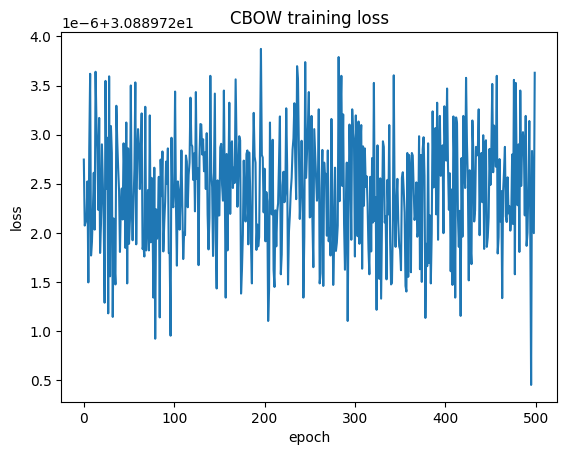

In [41]:
# ---- Train ----
sherlock_cbow_losses = []
for epoch in range(1, 501):
    total = 0.0
    for ctx, tgt in sherlock_cbow_loader:
        sherlock_cbow_opt.zero_grad()
        loss = sherlock_cbow_loss_fn(cbow_model(ctx), tgt)
        loss.backward()
        sherlock_cbow_opt.step()
        total += loss.item() * len(tgt)
    sherlock_cbow_losses.append(total / len(sherlock_cbow_y))
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:3d} | loss {sherlock_cbow_losses[-1]:.4f}")

plt.plot(sherlock_cbow_losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("CBOW training loss"); plt.show()

Vector for 'holmes': tensor([ 1.1800,  1.4900,  2.7800,  2.9000, -2.9400, -0.6900, -1.1300,  1.5500,
         2.3800,  2.5200, -1.8500, -0.6000,  2.6700, -2.3600, -1.0000, -0.9000,
         0.1400, -0.8600, -1.1300, -3.7300])


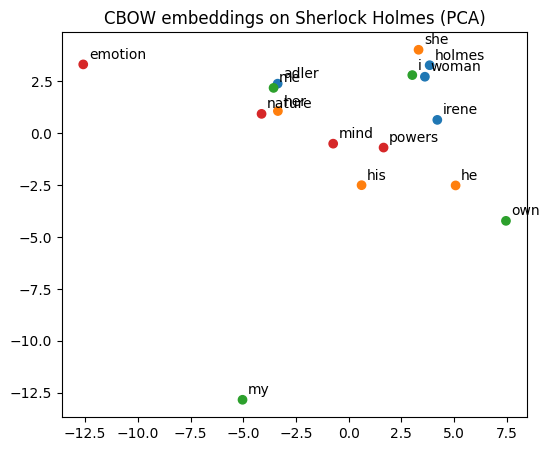

In [42]:
# ---- Extract vectors + PCA plot ----
sherlock_cbow_matrix = cbow_model.embeddings.weight.detach().clone()          # (V, D)
sherlock_cbow_vectors = {w: sherlock_cbow_matrix[i] for i, w in enumerate(sherlock_cbow_itos) if w != "<pad>"}
print("Vector for 'holmes':", sherlock_cbow_vectors["holmes"].round(decimals=2))

WORD_GROUPS = {                                   # Words that survive MIN_COUNT = 2 in this passage
    "people":    ["holmes", "irene", "adler", "woman"],
    "pronouns":  ["he", "his", "she", "her"],
    "narrator":  ["i", "my", "me", "own"],
    "mind":      ["mind", "emotion", "nature", "powers"],
}

def plot_embeddings_2d(vecs_dict, title):
    palette = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    words, colors = zip(*[(w, palette[g]) for g, grp in enumerate(WORD_GROUPS.values())
                          for w in grp if w in vecs_dict])          # Skip any word that was filtered out
    pts = PCA(n_components=2).fit_transform(np.stack([np.asarray(vecs_dict[w]) for w in words]))
    plt.figure(figsize=(6, 5)); plt.scatter(pts[:, 0], pts[:, 1], c=colors)
    for (x, y), w in zip(pts, words):
        plt.annotate(w, (x, y), textcoords="offset points", xytext=(4, 4))
    plt.title(title); plt.show()

plot_embeddings_2d(sherlock_cbow_vectors, "CBOW embeddings on Sherlock Holmes (PCA)")

---
# Part 5 — Using Pretrained Embeddings

Training good embeddings needs billions of words. Instead, we can download vectors that someone already trained, such as **GloVe** (Stanford), **word2vec** (Google News) or **fastText** (Facebook).

`gensim.downloader` fetches them and returns a **`KeyedVectors`** object: essentially our `cbow_vectors` dictionary from Part 4, plus many helpful methods.

> The first download of `glove-wiki-gigaword-50` is about 66 MB; it is cached afterwards (in `~/gensim-data`).

In [43]:
# ---- See what's available and load 50-dimensional GloVe vectors ----
import gensim.downloader as api                 # Gensim's model downloader

print([name for name in api.info()["models"] if not name.startswith("__")])  # All downloadable models
glove = api.load("glove-wiki-gigaword-50")      # Returns a gensim KeyedVectors object
print(type(glove))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200']
<class 'gensim.models.keyedvectors.KeyedVectors'>


## 5.1 Common `KeyedVectors` functions

In [44]:
# ---- Inspecting the vocabulary and individual vectors ----
print("vector size   :", glove.vector_size)     # Dimension of each vector (50)
print("vocab size    :", len(glove.key_to_index))  # Number of words (400,000)
print("first 10 words:", glove.index_to_key[:10])  # Words ordered by frequency (index 0 = most frequent)
print("'king' in vocab:", "king" in glove)      # Membership test
print("index of 'king':", glove.key_to_index["king"])  # Word -> row number
print("glove['king'][:5] =", glove["king"][:5])  # Word -> numpy vector (same as glove.get_vector('king'))
print("matrix shape  :", glove.vectors.shape)   # The full (vocab, dim) embedding matrix

vector size   : 50
vocab size    : 400000
first 10 words: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"]
'king' in vocab: True
index of 'king': 691
glove['king'][:5] = [ 0.50451   0.68607  -0.59517  -0.022801  0.60046 ]
matrix shape  : (400000, 50)


In [45]:
# ---- Similarity queries ----
print("similarity(cat, dog)   :", glove.similarity("cat", "dog"))      # Cosine similarity of two words
print("similarity(cat, truck) :", glove.similarity("cat", "truck"))
print("distance(cat, dog)     :", glove.distance("cat", "dog"))        # 1 - cosine similarity
print("most_similar('happy')  :", glove.most_similar("happy", topn=5)) # Nearest neighbours
print("doesnt_match           :", glove.doesnt_match(["apple", "banana", "mango", "car"]))  # Odd one out
print("n_similarity           :", glove.n_similarity(["king", "queen"], ["man", "woman"]))  # Mean-vector sets

similarity(cat, dog)   : 0.9218005
similarity(cat, truck) : 0.3101073
distance(cat, dog)     : 0.078199506
most_similar('happy')  : [("'m", 0.9142323136329651), ('everyone', 0.8976402282714844), ('everybody', 0.8965489864349365), ('really', 0.88397616147995), ('me', 0.8784631490707397)]
doesnt_match           : car
n_similarity           : 0.56535286


In [46]:
# ---- Analogies via vector arithmetic: king - man + woman ≈ ? ----
print(glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3))     # Expect 'queen'
print(glove.most_similar(positive=["paris", "italy"], negative=["france"], topn=3)) # Expect 'rome'
print(glove.most_similar_cosmul(positive=["walking", "swam"], negative=["walked"], topn=3))  # Tense analogy (multiplicative variant)

custom = glove["good"] - glove["bad"]           # You can also do the arithmetic yourself ...
print(glove.similar_by_vector(custom, topn=5))  # ... and search by an arbitrary vector

[('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172)]
[('rome', 0.8465589284896851), ('milan', 0.7766007781028748), ('turin', 0.7666355967521667)]
[('swim', 1.0407624244689941), ('swims', 1.0237160921096802), ('canoeing', 1.0099544525146484)]
[('70-member', 0.5359227061271667), ('4x200', 0.5251796841621399), ('ideal', 0.5032371282577515), ('holds', 0.5024096965789795), ('4x200m', 0.4999748766422272)]


**Freeze or fine-tune?**

- `freeze=True` keeps pretrained vectors fixed: safer with small datasets and keeps unseen words consistent with seen ones (as above).
- `freeze=False` lets training adjust them to your task: usually better with lots of labelled data.

**Other handy I/O functions**

```python
from gensim.models import KeyedVectors
glove.save("glove50.kv")                                     # Fast native gensim format
kv = KeyedVectors.load("glove50.kv")                         # ... and load it back
kv = KeyedVectors.load_word2vec_format("GoogleNews-vectors-negative300.bin", binary=True)  # Original word2vec file
kv = KeyedVectors.load_word2vec_format("glove.6B.50d.txt", binary=False, no_header=True)   # Raw GloVe text file
torch_weights = torch.tensor(kv.vectors)                     # Whole matrix -> PyTorch in one line
```

---
# Part 6 — How Gensim Abstracts All of This

Everything we built by hand in Part 4 (vocabulary, sliding windows, the model, the training loop, extracting the matrix) is a single call to `gensim.models.Word2Vec`.

| What we wrote in Part 4 | Gensim equivalent |
|---|---|
| `cbow_itos`, `cbow_stoi` | `model.wv.index_to_key`, `model.wv.key_to_index` (built automatically; `min_count` drops rare words) |
| `WINDOW = 2`, `make_cbow_pairs` | `window=2` (pairs are generated on the fly) |
| `CBOW_DIM = 20`, `nn.Embedding(V, D)` | `vector_size=20` |
| Averaging context vectors | `sg=0` (CBOW) with `cbow_mean=1` (use `sg=1` for skip-gram) |
| Full softmax over the vocabulary | `negative=5` (negative sampling) or `hs=1` (hierarchical softmax) |
| The epoch loop + Adam | `epochs=...`, `alpha` (learning rate, linearly decayed), SGD in optimised C code |
| `cbow_model.embeddings.weight` | `model.wv.vectors` |
| `most_similar(...)` we wrote | `model.wv.most_similar(...)` — the same `KeyedVectors` API as Part 5 |

**Why negative sampling?** Full softmax computes a score for *every* vocabulary word on every step, i.e. $O(V)$ work, which is painful when $V$ = 1,000,000. Negative sampling instead turns the problem into a few binary questions: *is this the real target?* (yes) and *are these $k$ random words the target?* (no). That costs $O(k)$ per step.

In [47]:
# ---- Train CBOW with gensim on the SAME toy corpus from Part 4 ----
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=tokenized_corpus,                 # List of token lists (exactly what we built in 4.1)
    vector_size=20,                             # Embedding dimension D
    window=2,                                   # Context words on each side
    min_count=1,                                # Keep every word (default 5 would drop rare words)
    sg=0,                                       # 0 = CBOW, 1 = skip-gram
    cbow_mean=1,                                # Average (not sum) the context vectors, like our model
    negative=5,                                 # 5 negative samples per positive example
    epochs=50,                                  # Passes over the corpus
    seed=SEED,                                  # Reproducible initialisation
    workers=1,                                  # 1 thread -> fully deterministic results
)
print(w2v)                                      # Summary: vocab size, vector size, learning rate

Word2Vec<vocab=129, vector_size=20, alpha=0.025>


In [48]:
# ---- Getting the dense embeddings of every word ----
wv = w2v.wv                                     # The trained KeyedVectors (same type as `glove` in Part 5)
print("matrix shape:", wv.vectors.shape)        # (vocab size, 20): every word's embedding
print("first words :", wv.index_to_key[:8])     # Sorted by frequency

gensim_vectors = {word: wv[word] for word in wv.index_to_key}  # Word -> vector dictionary, like cbow_vectors
print("vector for 'king':", np.round(gensim_vectors["king"], 2))

matrix shape: (129, 20)
first words : ['the', 'a', 'to', 'on', 'we', 'is', 'she', 'he']
vector for 'king': [-0.11  0.42 -0.34  0.03  0.76 -0.57  0.19  0.73 -0.06 -1.   -0.08 -0.66
 -0.36 -0.45  1.15  0.68  0.83 -0.58 -0.18  0.61]


In [49]:
# ---- Compare neighbours: our manual CBOW vs. gensim CBOW ----
for w in ["cat", "apple", "king", "car"]:
    manual = [x for x, _ in most_similar(w, cbow_matrix, cbow_stoi, cbow_itos, topn=4)]
    gens = [x for x, _ in wv.most_similar(w, topn=4)]
    print(f"{w:6s} | manual: {manual} | gensim: {gens}")

cat    | manual: ['horse', 'cow', 'mouse', 'dog'] | gensim: ['pig', 'sheep', 'dog', 'duck']
apple  | manual: ['cherry', 'pear', 'mango', 'orange'] | gensim: ['pear', 'plum', 'orange', 'banana']
king   | manual: ['queen', 'princess', 'empress', 'sultan'] | gensim: ['empress', 'monarch', 'sultan', 'duchess']
car    | manual: ['scooter', 'motorcycle', 'jeep', 'taxi'] | gensim: ['scooter', 'truck', 'tractor', 'ambulance']


In [50]:
# ---- Skip-gram is just a flag away ----
w2v_sg = Word2Vec(tokenized_corpus, vector_size=20, window=2, min_count=1,
                  sg=1,                          # Skip-gram: predict each context word FROM the target
                  negative=5, epochs=50, seed=SEED, workers=1)
print("skip-gram neighbours of 'queen':", w2v_sg.wv.most_similar("queen", topn=4))

skip-gram neighbours of 'queen': [('sultan', 0.9765780568122864), ('duchess', 0.9494255781173706), ('princess', 0.9330150485038757), ('king', 0.9307913780212402)]


In [51]:
# ---- Continue training with new sentences (the vocabulary can grow) ----
new_sentences = [["the", "tiger", "runs", "in", "the", "field"],
                 ["the", "tiger", "sleeps", "on", "the", "grass"],
                 ["a", "small", "tiger", "plays", "outside"]] * 20  # Repeat so the new word gets enough updates

w2v.build_vocab(new_sentences, update=True)     # update=True ADDS new words instead of starting over
w2v.train(new_sentences, total_examples=len(new_sentences), epochs=w2v.epochs)  # Train on the new data
print("'tiger' is now in the vocabulary:", "tiger" in w2v.wv)
print("neighbours of 'tiger':", w2v.wv.most_similar("tiger", topn=4))  # Should resemble the animals

'tiger' is now in the vocabulary: True
neighbours of 'tiger': [('cow', 0.9049018621444702), ('horse', 0.9005975127220154), ('dog', 0.889638364315033), ('duck', 0.8820589184761047)]


In [52]:
# ---- Saving and loading ----
w2v.save("toy_word2vec.model")                  # Full model: can be trained further after loading
reloaded = Word2Vec.load("toy_word2vec.model")
w2v.wv.save("toy_vectors.kv")                   # Just the vectors: smaller, read-only, faster
w2v.wv.save_word2vec_format("toy_vectors.txt")  # Plain-text format readable by other tools
print("reloaded vector matches:", np.allclose(reloaded.wv["king"], w2v.wv["king"]))

# ---- Handing gensim vectors to PyTorch (closing the loop with Part 5) ----
emb_layer = nn.Embedding.from_pretrained(torch.tensor(w2v.wv.vectors), freeze=True)  # (V, 20) lookup table
print("PyTorch embedding layer:", emb_layer)

reloaded vector matches: True
PyTorch embedding layer: Embedding(130, 20)


In [53]:
# ---- Bonus: FastText builds vectors from character n-grams, so it can embed unseen words ----
from gensim.models import FastText

ft = FastText(tokenized_corpus, vector_size=20, window=2, min_count=1, epochs=30, seed=SEED, workers=1)
print("'kingg' in vocabulary?", "kingg" in ft.wv.key_to_index)  # False: never seen (a typo)
print("but it still has a vector:", ft.wv["kingg"].shape)       # Assembled from n-grams like 'kin', 'ing', 'ngg'
print("similarity(kingg, king):", round(float(ft.wv.similarity("kingg", "king")), 3))

'kingg' in vocabulary? False
but it still has a vector: (20,)
similarity(kingg, king): 0.998


---
# Summary

| Part | Key idea |
|---|---|
| 1 | Tensors hold data; `requires_grad=True` + `.backward()` gives gradients for free. |
| 2 | A network = linear layers + non-linear activations. Backprop is the chain rule; gradient descent steps against the gradient. |
| 3 | Real pipelines: tokenise → vocab → pad → `DataLoader` → model → `zero_grad/forward/loss/backward/step`. |
| 4 | CBOW predicts a word from its neighbours; the learned `nn.Embedding` weight matrix **is** the set of word vectors. |
| 5 | Pretrained vectors (`KeyedVectors`) give similarity, analogies, and a head start via `nn.Embedding.from_pretrained`. |
| 6 | `gensim.Word2Vec` packages Part 4 into one efficient call, with negative sampling, skip-gram, and incremental training. |

**Where to go next:** replace averaging with an RNN/LSTM or a Transformer so the model sees word order, and compare contextual embeddings (BERT) with the static embeddings from this notebook.

---
# Bonus — A Complete Example: 3-Class Sentiment Analysis

The goal here is to see **every step of the pipeline**, not to reach state-of-the-art accuracy. We'll classify short reviews as **negative (0)**, **neutral (1)** or **positive (2)**.

The pipeline:

1. **Create data** — 300 synthetic sentences (100 per class).
2. **Split** — train / validation / test.
3. **Tokenise & build a vocabulary** — map each word to an integer id.
4. **Encode & pad** — turn sentences into fixed-length integer tensors.
5. **Dataset & DataLoader** — serve mini-batches.
6. **Model** — Embedding → average → hidden layer (ReLU) → 3 output scores.
7. **Train** — the 5-line loop from Part 2, now with mini-batches and validation.
8. **Evaluate & predict** — accuracy, confusion matrix, predictions on new sentences.

## Step 1: Create a small synthetic dataset

In [54]:
# ---- Word lists: each sentiment class has its own adjectives and verbs; nouns are shared ----
random.seed(SEED)                               # Make the dataset identical on every run

LABELS = ["negative", "neutral", "positive"]    # Index 0, 1, 2 -> human-readable name

ADJECTIVES = {
    0: ["terrible", "awful", "horrible", "boring", "disappointing", "poor", "dreadful", "bad"],
    1: ["okay", "average", "ordinary", "typical", "standard", "fine", "acceptable", "normal"],
    2: ["great", "amazing", "excellent", "wonderful", "fantastic", "delightful", "superb", "enjoyable"],
}
VERBS = {
    0: ["hated", "disliked", "regretted", "despised"],
    1: ["watched", "used", "bought", "tried"],
    2: ["loved", "enjoyed", "adored", "liked"],
}
NOUNS = ["movie", "phone", "meal", "book", "service", "hotel", "game", "song"]  # Shared by all classes

TEMPLATES = [                                   # Sentence patterns with slots to fill
    "the {noun} was {adj}",
    "i {verb} this {noun}",
    "this {noun} is {adj}",
    "i {verb} the {noun} it was {adj}",
    "overall a {adj} {noun}",
    "honestly the {noun} felt {adj}",
]


def make_sentence(label):
    # ---- Fill a random template with random words belonging to `label` ----
    template = random.choice(TEMPLATES)         # Pick a pattern
    return template.format(                     # .format ignores slots the template doesn't use
        noun=random.choice(NOUNS),
        adj=random.choice(ADJECTIVES[label]),
        verb=random.choice(VERBS[label]),
    )


data = [(make_sentence(label), label)           # List of (sentence, label) pairs
        for label in range(3)                   # For each of the 3 classes ...
        for _ in range(100)]                    # ... create 100 sentences -> 300 total
random.shuffle(data)                            # Mix the classes together

print("Total examples:", len(data))
print("Class counts:", Counter(label for _, label in data))
for sentence, label in data[:6]:                # Peek at a few examples
    print(f"  [{LABELS[label]:8s}] {sentence}")

Total examples: 300
Class counts: Counter({0: 100, 1: 100, 2: 100})
  [negative] honestly the phone felt terrible
  [neutral ] i used the hotel it was acceptable
  [neutral ] this meal is average
  [positive] overall a superb movie
  [negative] the service was horrible
  [negative] i regretted this game


## Step 2: Split into train / validation / test

- **Train** (70%): the model learns from these.
- **Validation** (15%): used during training to watch for overfitting.
- **Test** (15%): touched only once at the very end for an honest score.

In [55]:
# ---- 70 / 15 / 15 split of the (already shuffled) data ----
n = len(data)
n_train, n_val = int(0.70 * n), int(0.15 * n)   # 210 and 45
train_data = data[:n_train]                     # First 70%
val_data = data[n_train:n_train + n_val]        # Next 15%
test_data = data[n_train + n_val:]              # Remaining 15%
print(f"train={len(train_data)}  val={len(val_data)}  test={len(test_data)}")

train=210  val=45  test=45


## Step 3: Tokenisation and vocabulary

Neural networks only understand numbers, so each word gets an integer id. Two special tokens are reserved:

- `<pad>` (id 0): filler used to make every sentence the same length.
- `<unk>` (id 1): any word not seen during training.

The vocabulary is built **from the training set only**; otherwise information about the test set would leak into the model.

In [56]:
# ---- Build the word <-> id mappings ----
def tokenize(text):
    return text.lower().split()                 # Simplest possible tokenizer: lowercase + split on spaces


word_counts = Counter(tok for sentence, _ in train_data for tok in tokenize(sentence))  # Count training words
PAD, UNK = "<pad>", "<unk>"                     # Special tokens
itos = [PAD, UNK] + sorted(word_counts)         # "index to string": list where position = id
stoi = {word: idx for idx, word in enumerate(itos)}  # "string to index": dictionary word -> id
PAD_IDX, UNK_IDX = stoi[PAD], stoi[UNK]         # 0 and 1

print("Vocabulary size:", len(itos))
print("First 12 entries:", itos[:12])
print("id of 'movie':", stoi["movie"])

Vocabulary size: 56
First 12 entries: ['<pad>', '<unk>', 'a', 'acceptable', 'adored', 'amazing', 'average', 'awful', 'bad', 'book', 'boring', 'bought']
id of 'movie': 35


## Step 4: Encoding and padding

In [57]:
# ---- Convert sentences to fixed-length lists of ids ----
MAX_LEN = max(len(tokenize(s)) for s, _ in data)  # Longest sentence decides the padded length


def encode(sentence, vocab=None):
    vocab = vocab or stoi                       # Default to the vocabulary built above
    return [vocab.get(tok, vocab[UNK]) for tok in tokenize(sentence)]  # Unknown words -> <unk>


def pad(ids, max_len=MAX_LEN):
    ids = ids[:max_len]                         # Truncate if too long
    return ids + [PAD_IDX] * (max_len - len(ids))  # Append <pad> ids until length == max_len


example = train_data[0][0]
print("sentence :", example)
print("tokens   :", tokenize(example))
print("ids      :", encode(example))
print("padded   :", pad(encode(example)))
print("unknown  :", encode("the movie was spectacular"))  # 'spectacular' is not in the vocab -> 1

sentence : honestly the phone felt terrible
tokens   : ['honestly', 'the', 'phone', 'felt', 'terrible']
ids      : [26, 48, 40, 21, 47]
padded   : [26, 48, 40, 21, 47, 0, 0]
unknown  : [48, 35, 53, 1]


## Step 5: `Dataset` and `DataLoader`

A `Dataset` answers two questions: *how many examples?* (`__len__`) and *give me example i* (`__getitem__`). A `DataLoader` wraps it to produce shuffled mini-batches.

In [58]:
# ---- Wrap the encoded data so PyTorch can batch and shuffle it ----
class SentimentDataset(Dataset):
    def __init__(self, pairs, vocab=None):
        # Pre-encode every sentence once and store the results as tensors
        self.x = torch.tensor([pad(encode(s, vocab)) for s, _ in pairs], dtype=torch.long)  # (N, MAX_LEN)
        self.y = torch.tensor([label for _, label in pairs], dtype=torch.long)             # (N,)

    def __len__(self):
        return len(self.y)                      # Number of examples

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]         # One (input ids, label) pair


BATCH_SIZE = 16
train_ds, val_ds, test_ds = SentimentDataset(train_data), SentimentDataset(val_data), SentimentDataset(test_data)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)  # Shuffle each epoch for training
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)                    # No need to shuffle evaluation data
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

xb, yb = next(iter(train_loader))               # Grab one batch to inspect
print("batch inputs shape:", xb.shape)          # (BATCH_SIZE, MAX_LEN)
print("batch labels shape:", yb.shape)          # (BATCH_SIZE,)
print("first row:", xb[0].tolist(), "-> label", yb[0].item())

batch inputs shape: torch.Size([16, 7])
batch labels shape: torch.Size([16])
first row: [26, 48, 34, 21, 51, 0, 0] -> label 1


## Step 6: The model

```
word ids (B, L) ──Embedding──► (B, L, D) ──masked mean──► (B, D) ──Linear+ReLU ──► (B, H) ──Linear──► logits (B, 3)
```

- **`nn.Embedding`** is a lookup table: row *i* is the learned dense vector for word *i*. (This is exactly what Parts 4–6 are about.)
- **Masked mean** averages the word vectors, ignoring `<pad>` positions, to get one vector per sentence.
- The output is 3 raw scores (**logits**). `nn.CrossEntropyLoss` applies softmax internally, so we don't add one.

The optional `pretrained` argument will be used in Part 5.

In [59]:
# ---- Embedding-bag style classifier ----
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx,
                 pretrained=None, freeze=False):
        super().__init__()
        if pretrained is not None:              # Part 5: start from existing word vectors
            self.embedding = nn.Embedding.from_pretrained(pretrained, freeze=freeze, padding_idx=pad_idx)
        else:                                   # Otherwise learn embeddings from scratch
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pad_idx = pad_idx
        self.fc1 = nn.Linear(self.embedding.embedding_dim, hidden_dim)  # Sentence vector -> hidden layer
        self.relu = nn.ReLU()                   # Non-linearity
        self.fc2 = nn.Linear(hidden_dim, num_classes)  # Hidden layer -> one score per class

    def forward(self, x):                       # x: (B, L) integer ids
        emb = self.embedding(x)                 # (B, L, D): look up a vector for every token
        mask = (x != self.pad_idx).unsqueeze(-1).float()  # (B, L, 1): 1 for real words, 0 for padding
        summed = (emb * mask).sum(dim=1)        # (B, D): add up only the real word vectors
        lengths = mask.sum(dim=1).clamp(min=1)  # (B, 1): number of real words (avoid dividing by 0)
        sentence_vec = summed / lengths         # (B, D): average word vector = sentence representation
        hidden = self.relu(self.fc1(sentence_vec))  # (B, H)
        return self.fc2(hidden)                 # (B, num_classes) logits


torch.manual_seed(SEED)
EMBED_DIM, HIDDEN_DIM = 16, 32
model = SentimentClassifier(len(itos), EMBED_DIM, HIDDEN_DIM, num_classes=3, pad_idx=PAD_IDX)
print(model)
n_params = sum(p.numel() for p in model.parameters())  # Count every learnable number
print("Trainable parameters:", n_params)

SentimentClassifier(
  (embedding): Embedding(56, 16, padding_idx=0)
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)
Trainable parameters: 1539


### Walking one batch through the model

Before training, let's trace the shapes step by step so nothing is a black box.

In [60]:
# ---- Manually replay the forward pass on the batch we grabbed earlier ----
with torch.no_grad():                           # Just inspecting, no training
    emb = model.embedding(xb)
    print("1. embedding lookup  :", tuple(emb.shape), " (batch, tokens, embed_dim)")
    mask = (xb != PAD_IDX).unsqueeze(-1).float()
    print("2. padding mask      :", tuple(mask.shape), " real-word counts:", mask.sum(1).squeeze().int().tolist()[:5], "...")
    sent = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)
    print("3. sentence vectors  :", tuple(sent.shape))
    hid = model.relu(model.fc1(sent))
    print("4. hidden layer      :", tuple(hid.shape))
    logits = model.fc2(hid)
    print("5. logits            :", tuple(logits.shape))
    probs = F.softmax(logits, dim=1)
    print("6. softmax (row 0)   :", probs[0].round(decimals=3).tolist(), "<- roughly uniform before training")
    print("   loss on this batch:", F.cross_entropy(logits, yb).item(), "(≈ ln 3 = 1.099 for random guessing)")

1. embedding lookup  : (16, 7, 16)  (batch, tokens, embed_dim)
2. padding mask      : (16, 7, 1)  real-word counts: [5, 4, 7, 4, 4] ...
3. sentence vectors  : (16, 16)
4. hidden layer      : (16, 32)
5. logits            : (16, 3)
6. softmax (row 0)   : [0.4059999883174896, 0.2879999876022339, 0.3050000071525574] <- roughly uniform before training
   loss on this batch: 1.1106927394866943 (≈ ln 3 = 1.099 for random guessing)


## Step 7: Training loop with validation

In [61]:
# ---- Reusable evaluation and training functions ----
@torch.no_grad()                                # Decorator: no gradient tracking inside this function
def evaluate(model, loader, loss_fn):
    model.eval()                                # Switch layers like dropout to evaluation mode
    total_loss, correct, count = 0.0, 0, 0
    for xb, yb in loader:
        logits = model(xb)                      # Forward pass
        total_loss += loss_fn(logits, yb).item() * len(yb)  # Sum of per-example losses
        correct += (logits.argmax(dim=1) == yb).sum().item()  # Highest score = predicted class
        count += len(yb)
    return total_loss / count, correct / count  # Average loss, accuracy


def train_model(model, train_loader, val_loader, epochs=25, lr=0.01, verbose=True):
    loss_fn = nn.CrossEntropyLoss()             # Softmax + negative log-likelihood in one function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam: gradient descent with adaptive step sizes
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):          # One epoch = one pass over the training set
        model.train()                           # Training mode
        running = 0.0
        for xb, yb in train_loader:             # Mini-batch gradient descent
            optimizer.zero_grad()               # 1) reset gradients
            logits = model(xb)                  # 2) forward pass
            loss = loss_fn(logits, yb)          # 3) loss
            loss.backward()                     # 4) backpropagation
            optimizer.step()                    # 5) update weights
            running += loss.item() * len(yb)

        train_loss = running / len(train_loader.dataset)       # Average training loss this epoch
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)  # Check generalisation
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f"epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.2%}")
    return history


history = train_model(model, train_loader, val_loader)

epoch  1 | train loss 1.0984 | val loss 1.0487 | val acc 46.67%
epoch  5 | train loss 0.2332 | val loss 0.1038 | val acc 100.00%
epoch 10 | train loss 0.0044 | val loss 0.0061 | val acc 100.00%
epoch 15 | train loss 0.0016 | val loss 0.0030 | val acc 100.00%
epoch 20 | train loss 0.0009 | val loss 0.0019 | val acc 100.00%
epoch 25 | train loss 0.0006 | val loss 0.0014 | val acc 100.00%


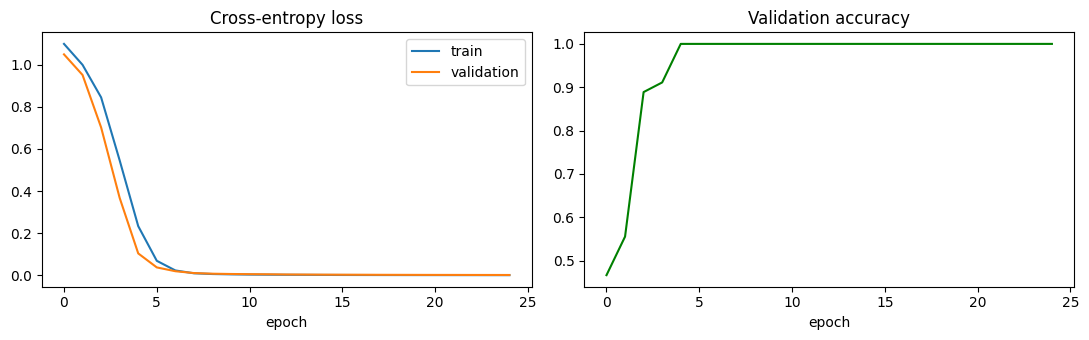

In [62]:
# ---- Plot the learning curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="validation")
ax1.set_title("Cross-entropy loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(history["val_acc"], color="green"); ax2.set_title("Validation accuracy"); ax2.set_xlabel("epoch")
plt.tight_layout(); plt.show()
# If validation loss started rising while training loss kept falling, that would signal overfitting.

## Step 8: Final evaluation and predictions

In [63]:
# ---- Test accuracy and a confusion matrix ----
test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
print(f"Test accuracy: {test_acc:.2%}")

confusion = torch.zeros(3, 3, dtype=torch.long) # Rows = true class, columns = predicted class
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb).argmax(dim=1)         # Predicted class per example
        for t, p in zip(yb, preds):
            confusion[t, p] += 1                # Tally each (true, predicted) pair

print("\nConfusion matrix (rows=true, cols=pred):")
print(f"{'':>10}" + "".join(f"{l:>10}" for l in LABELS))
for i, row in enumerate(confusion):
    print(f"{LABELS[i]:>10}" + "".join(f"{v:>10}" for v in row.tolist()))

Test accuracy: 100.00%

Confusion matrix (rows=true, cols=pred):
            negative   neutral  positive
  negative        16         0         0
   neutral         0        16         0
  positive         0         0        13


In [64]:
# ---- Predict the sentiment of brand-new sentences ----
def predict(model, sentence, vocab=None):
    model.eval()
    ids = torch.tensor([pad(encode(sentence, vocab))])  # Encode + pad, then add a batch dimension -> (1, L)
    with torch.no_grad():
        probs = F.softmax(model(ids), dim=1)[0]  # Convert logits to probabilities
    label = LABELS[probs.argmax().item()]
    return label, {LABELS[i]: round(p, 3) for i, p in enumerate(probs.tolist())}


for s in ["the hotel was wonderful",
          "i hated the song",
          "the meal was average",
          "honestly the phone felt spectacular"]:  # 'spectacular' was never seen -> <unk>
    print(f"{s!r:40} -> {predict(model, s)}")

'the hotel was wonderful'                -> ('positive', {'negative': 0.0, 'neutral': 0.0, 'positive': 1.0})
'i hated the song'                       -> ('negative', {'negative': 0.999, 'neutral': 0.0, 'positive': 0.001})
'the meal was average'                   -> ('neutral', {'negative': 0.0, 'neutral': 1.0, 'positive': 0.0})
'honestly the phone felt spectacular'    -> ('negative', {'negative': 0.421, 'neutral': 0.272, 'positive': 0.307})


**Takeaways**

- The embedding layer learned a vector for each word *as a side effect* of learning to classify sentiment.
- The last sentence shows a weakness: the model knows nothing about words it never saw (`spectacular` → `<unk>`). **Pretrained embeddings** help with exactly this.
- Averaging word vectors ignores word order, so this model would struggle with negation ("not good"). Real datasets need richer models (RNNs, Transformers), but the training process is the same.